# Project_Yeast_Saif_Approach_2

## 1. Trmming_pysam + indexing bam file
Trimming the last 30 nucleotides from aligned long reads in Scer.sorted.bam, considering only reads with FLAG values 0 (forward strand) and 16 (reverse strand), using pysam.

In [1]:
!pip install biopython
!pip install pysam


import pysam
from Bio.Seq import Seq  # for reverse-complement

input_bam = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/longReads/Scer.sorted.bam"
output_bam = "/home/ldufour/Documents/Saif_project_Yeast/Trimming/output_reverseCorrected_last30.bam"
read_length = 30

with pysam.AlignmentFile(input_bam, "rb") as infile, \
     pysam.AlignmentFile(output_bam, "wb", template=infile) as outfile:

    for read in infile.fetch():
        if read.flag not in {0, 16}:
            continue  # keep only forward (0) and reverse (16)

        if read.query_length < read_length:
            continue

        # Get the aligned pairs
        aligned_pairs = read.get_aligned_pairs(matches_only=True)
        if len(aligned_pairs) < read_length:
            continue

        # Prepare new read object
        new_read = read.__copy__()

        if read.flag == 0:
            # Forward strand: last 30 nt from the 3' end
            trimmed_seq = read.query_sequence[-read_length:]
            trimmed_qual = read.query_qualities[-read_length:] if read.query_qualities else None
            new_start = aligned_pairs[-read_length][1]
            new_read.pos = new_start
        else:
            # Reverse strand: last 30 nt is from the 5' end (in read space), reverse complement it
            trimmed_seq = str(Seq(read.query_sequence[:read_length]).reverse_complement())
            if read.query_qualities:
                trimmed_qual = read.query_qualities[:read_length][::-1]
            else:
                trimmed_qual = None
            new_start = aligned_pairs[read_length - 1][1]  # start at the last of the first 30 aligned bases
            new_read.pos = new_start

        # Update the new read
        new_read.query_sequence = trimmed_seq
        new_read.query_qualities = trimmed_qual
        new_read.cigar = [(0, read_length)]  # 30M match
        outfile.write(new_read)

print("Output saved to:", output_bam)


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Output saved to: /home/ldufour/Documents/Saif_project_Yeast/Trimming/output_reverseCorrected_last30.bam


**Note:** new path: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30.bam

Path Lara: /home/ldufour/Documents/Saif_project_Yeast/Trimming/output_reverseCorrected_last30.bam

In [3]:
%%bash 

module load SAMtools/1.19.2-GCC-13.3.0

samtools sort -o  /home/ldufour/Documents/Saif_project_Yeast/Trimming/output_reverseCorrected_last30_sorted.bam \
/home/ldufour/Documents/Saif_project_Yeast/Trimming/output_reverseCorrected_last30.bam

samtools index /home/ldufour/Documents/Saif_project_Yeast/Trimming/output_reverseCorrected_last30_sorted.bam


[bam_sort_core] merging from 11 files and 1 in-memory blocks...


## 2. Peak Caller: MASC2
performing peak calling using MACS2 with the same BAM file but three different parameter sets, aiming to evaluate which settings give the best peak results. Your final goal is to compare the outputs and select the optimal peak set for further analysis.

### 2.1 MASC2_last30

In [6]:
%%bash
## peak controller. MASC2

source /home/saif/anaconda3/bin/activate MASC2


macs2 callpeak \
-t /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
--outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/ \
-n last30 \
--nomodel \
--extsize 30


INFO  @ Wed, 14 May 2025 16:07:50: 
# Command line: callpeak -t /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam --outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/ -n last30 --nomodel --extsize 30
# ARGUMENTS LIST:
# name = last30
# format = AUTO
# ChIP-seq file = ['/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam']
# control file = None
# effective genome size = 2.70e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 5.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 10000 bps
# Broad region calling is off
# Paired-End mode is off
 
INFO  @ Wed, 14 May 2025 16:07:50: #1 read tag fil

### 2.2 MASC2_last30_1

In [7]:
%%bash
## peak controller. MASC2

source /home/saif/anaconda3/bin/activate MASC2



macs2 callpeak \
-t /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
--outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/ \
-n last30_1 \
--extsize 30 \
--keep-dup all \
-B --SPMR



INFO  @ Wed, 14 May 2025 16:08:51: 
# Command line: callpeak -t /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam --outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/ -n last30_1 --extsize 30 --keep-dup all -B --SPMR
# ARGUMENTS LIST:
# name = last30_1
# format = AUTO
# ChIP-seq file = ['/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam']
# control file = None
# effective genome size = 2.70e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 5.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 10000 bps
# Broad region calling is off
# Paired-End mode is off
# MACS will save fragment pileup 

### 2.3 MASC2_last30_2

In [8]:
%%bash
## peak controller. MASC2

source /home/saif/anaconda3/bin/activate MASC2

macs2 callpeak \
-t /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
--outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/ \
-n last30_2 \
--nomodel \
--extsize 30 \
--keep-dup auto \
-B --SPMR

INFO  @ Wed, 14 May 2025 16:11:31: 
# Command line: callpeak -t /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam --outdir /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/ -n last30_2 --nomodel --extsize 30 --keep-dup auto -B --SPMR
# ARGUMENTS LIST:
# name = last30_2
# format = AUTO
# ChIP-seq file = ['/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam']
# control file = None
# effective genome size = 2.70e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 5.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 10000 bps
# Broad region calling is off
# Paired-End mode is off
# MACS will save fragm

| Option           | Meaning                                                                 |
|------------------|-------------------------------------------------------------------------|
| `-t`             | Input BAM file of aligned reads                                         |
| `--outdir`       | Folder where peak results are saved                                     |
| `-n last30_2`    | Prefix for output file names                                            |
| `--nomodel`      | Disable MACS2’s default fragment size model                             |
| `--extsize 30`   | Manually extend each read by 30 bases (likely reflects last-30 nt use)  |
| `--keep-dup auto`| Let MACS2 decide how to deal with duplicate reads                       |
| `-B`             | Output a bedGraph signal track of read pileup                           |
| `--SPMR`         | Normalize signal to per million reads (for signal tracks)               |


### 2.4 Comparison of the Three Methods (Three MACS2 Parameter Sets)

The complete scripts used for each peak calling method, along with the steps for generating the comparison figure, are available in the following notebook:

 **Path:** `/home/saif/Documents/Saif_project_Yeast/approach2/count_size_difference.ipynb`

Additionally, an example of how the analysis was performed for one method (`last30_2`) is provided in **Section 3** of this document. This example demonstrates the general approach used for all three MACS2 configurations.


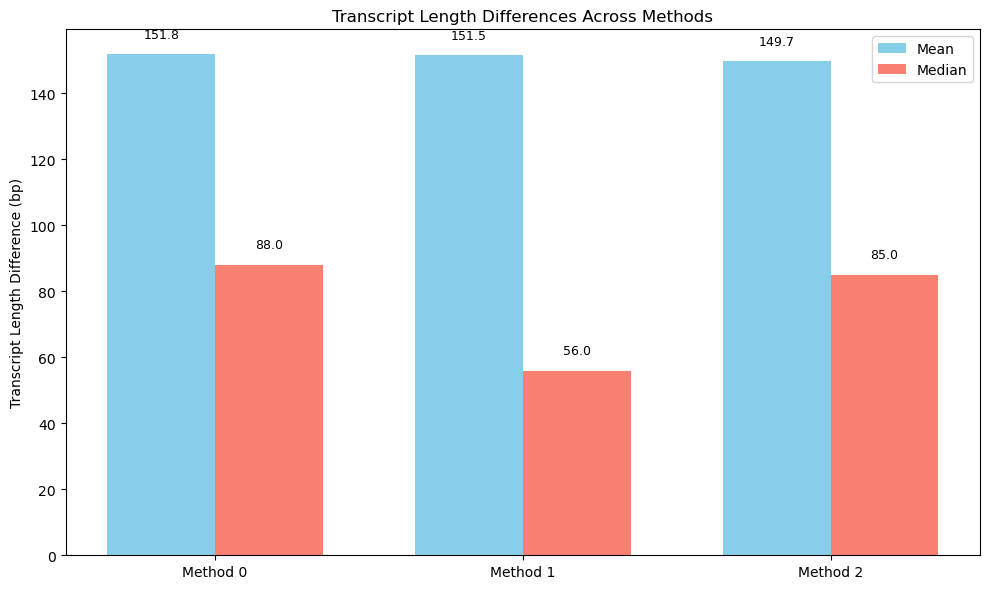

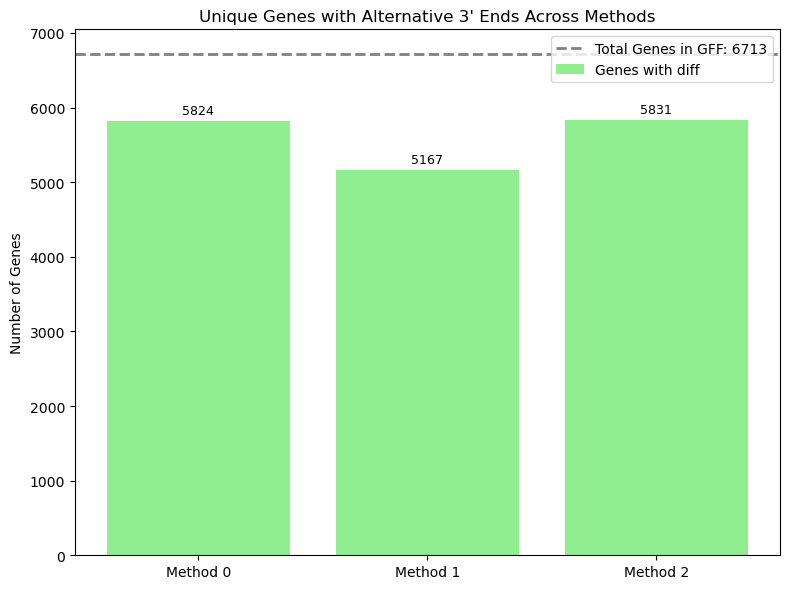

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths for 3 methods
paths = {
    "Method 0": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences_gtf_filtered.csv",
    "Method 1": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences_gtf_filtered.csv",
    "Method 2": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences_gtf_filtered.csv"
}

# Collect summary
summary_data = []
for method, path in paths.items():
    df = pd.read_csv(path)
    diffs = df["length_difference"].abs()
    summary_data.append({
        "Method": method,
        "Mean": diffs.mean(),
        "Median": diffs.median(),
        "Unique Genes": df["gene_id"].nunique()
    })

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# Plot mean/median differences
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(summary_df))
width = 0.35

ax.bar([i - width/2 for i in x], summary_df["Mean"], width, label="Mean", color="skyblue")
ax.bar([i + width/2 for i in x], summary_df["Median"], width, label="Median", color="salmon")

ax.set_xticks(x)
ax.set_xticklabels(summary_df["Method"])
ax.set_ylabel("Transcript Length Difference (bp)")
ax.set_title("Transcript Length Differences Across Methods")
ax.legend()

# Add labels
for i, row in summary_df.iterrows():
    ax.text(i - width/2, row["Mean"] + 5, f"{row['Mean']:.1f}", ha="center", fontsize=9)
    ax.text(i + width/2, row["Median"] + 5, f"{row['Median']:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


######### Plot: Unique Genes with Alternative 3' Ends Across Methods #########

import pandas as pd
import matplotlib.pyplot as plt

# Corrected total number of genes in GFF
reference_gene_count = 6713

# Paths for 3 methods
paths = {
    "Method 0": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_final_gene_length_differences_gtf_filtered.csv",
    "Method 1": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/final_gene_length_differences_gtf_filtered.csv",
    "Method 2": "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/trim30_2_final_gene_length_differences_gtf_filtered.csv"
}

# Collect summary
summary_data = []
for method, path in paths.items():
    df = pd.read_csv(path)
    diffs = df["length_difference"].abs()
    summary_data.append({
        "Method": method,
        "Mean": diffs.mean(),
        "Median": diffs.median(),
        "Unique Genes": df["gene_id"].nunique()
    })

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# === Bar plot of number of unique genes vs reference ===
fig, ax = plt.subplots(figsize=(8, 6))
x = range(len(summary_df))
bars = ax.bar(summary_df["Method"], summary_df["Unique Genes"], color="lightgreen", label="Genes with diff")

# Add horizontal reference line
ax.axhline(reference_gene_count, color='gray', linestyle='--', linewidth=2,
           label=f"Total Genes in GFF: {reference_gene_count}")

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 50, f"{int(height)}",
            ha='center', va='bottom', fontsize=9)

# Final plot styling
ax.set_ylabel("Number of Genes")
ax.set_title("Unique Genes with Alternative 3' Ends Across Methods")
ax.legend()
plt.tight_layout()
plt.show()



## 3. Creating an annotation file for new transcripts: based on MASC2_last30_2, narrowpeak_transcripts_trim30_2.gtf
**Main goal of section 3** To generate a GTF annotation of new transcripts/isoforms derived from MACS2 peak summits, and compare their lengths to the original annotations, particularly focusing on the longest isoform per gene.

**Goal of first step:** Derive new transcript annotations from MACS2 `last30_2` peak summits.
- **Method:** Match summit positions to original transcript coordinates and generate new GTF entries representing truncated isoforms.

In [12]:
!pip install gffutils

import pandas as pd
import gffutils
import os

# === File paths ===
GFF_FILE = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
NARROWPEAK_FILE = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/last30_2_peaks.narrowPeak"
DB_FILE = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.db"
OUTPUT_GTF = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf"

# === Load .narrowPeak and compute summit position ===
narrow_df = pd.read_csv(NARROWPEAK_FILE, sep='\t', header=None,
                        names=["chrom", "start", "end", "name", "score", "strand",
                               "signalValue", "pValue", "qValue", "peak"])

# Calculate summit position
narrow_df["summit_pos"] = narrow_df["start"] + narrow_df["peak"]
print(f"Total peaks loaded: {len(narrow_df)}")

# === Build or load GFF database ===
if not os.path.exists(DB_FILE):
    print("Creating GFF database...")
    gffutils.create_db(GFF_FILE, DB_FILE, merge_strategy="merge", keep_order=True)
db = gffutils.FeatureDB(DB_FILE)

# === Match summit positions to transcripts and build new entries ===
new_gtf_lines = []
seen = set()

for _, row in narrow_df.iterrows():
    chrom = row["chrom"]
    summit = int(row["summit_pos"])
    peak_name = row["name"]

    # Only get features where summit lies within transcript
    overlapping = db.region(region=(chrom, summit, summit + 1), completely_within=False)

    for feature in overlapping:
        if feature.featuretype not in ["mRNA", "transcript"]:
            continue

        if not (feature.start <= summit <= feature.end):
            continue

        gene_id = feature.attributes.get("gene_id", [None])[0] or feature.id
        strand = feature.strand

        if strand == "+":
            tx_start = feature.start
            tx_end = summit
        elif strand == "-":
            tx_start = summit
            tx_end = feature.end
        else:
            continue

        new_tx_id = f"{gene_id}_{peak_name}"
        if new_tx_id in seen:
            continue
        seen.add(new_tx_id)

        line = (
            f"{chrom}\tcustom\ttranscript\t{tx_start}\t{tx_end}\t.\t{strand}\t.\t"
            f'gene_id "{gene_id}"; transcript_id "{new_tx_id}";\n'
        )
        new_gtf_lines.append(line)

# === Write updated GTF ===
with open(OUTPUT_GTF, "w") as f:
    f.writelines(new_gtf_lines)

print(f"Updated transcript annotations saved to {OUTPUT_GTF}")

  Using cached gffutils-0.13-py3-none-any.whl.metadata (1.5 kB)
  Using cached argh-0.31.3-py3-none-any.whl.metadata (7.4 kB)
  Using cached argcomplete-3.6.2-py3-none-any.whl.metadata (16 kB)
Using cached gffutils-0.13-py3-none-any.whl (1.6 MB)
Using cached argcomplete-3.6.2-py3-none-any.whl (43 kB)
Using cached argh-0.31.3-py3-none-any.whl (44 kB)
Total peaks loaded: 8401
Creating GFF database...
Updated transcript annotations saved to /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf


### 3.1 Making an annotation file with the longest new transcript/isoform
**Goal:** Keep only the longest new transcript per gene from the custom GTF.

In [13]:

import pandas as pd

def parse_gtf(file_path):
    entries = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split('\t')
            if len(parts) != 9 or parts[2] != "transcript":
                continue
            seq_id, source, feature_type, start, end, score, strand, phase, attributes = parts
            attr_dict = {}
            for attr in attributes.strip().split(';'):
                if ' ' in attr:
                    key, value = attr.strip().split(' ', 1)
                    attr_dict[key.strip()] = value.strip().strip('"')
            transcript_id = attr_dict.get('transcript_id', '')
            gene_id = attr_dict.get('gene_id', transcript_id.split('_')[0])
            entries.append({
                "line": line.strip(),
                "seq_id": seq_id,
                "start": int(start),
                "end": int(end),
                "length": int(end) - int(start),
                
                "strand": strand,
                "transcript_id": transcript_id,
                "gene_id": gene_id
            })
    return pd.DataFrame(entries)

# Paths
input_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf"
output_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_longest_annotation.gtf"

# Parse the GTF
df = parse_gtf(input_gtf)

# Keep only the longest transcript per gene
longest_per_gene = df.sort_values(by="length", ascending=False).drop_duplicates(subset="gene_id")

# Write output
with open(output_gtf, "w") as f:
    for line in longest_per_gene['line']:
        f.write(line + "\n")

print(f"Longest transcript per gene saved to: {output_gtf}")

Longest transcript per gene saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_longest_annotation.gtf


### 3.2 Length_of_longest_transcript

In [14]:
from collections import defaultdict
import pandas as pd

# path to file
gtf_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_longest_annotation.gtf"

transcript_lengths = defaultdict(int)

# Parse GTF file
with open(gtf_file, 'r', encoding='utf-8', errors='ignore') as file:
    for line in file:
        if line.startswith("#"):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        try:
            start = int(parts[3])
            end = int(parts[4])
            length = end - start + 1
            attributes = parts[8]
            if 'transcript_id "' in attributes:
                tid = attributes.split('transcript_id "')[1].split('"')[0]
                transcript_lengths[tid] += length
        except:
            continue

# Set your output path
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_transcript_length_comparison.csv"

# Create DataFrame and save
df = pd.DataFrame([
    {"transcript_id": tid, "length": length}
    for tid, length in transcript_lengths.items()
])

df.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")


Saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_transcript_length_comparison.csv


### 3.3 Length of longest vs the original transcript

In [15]:
### original transcript length ###

#import pandas as pd
#import re

# === File paths ===
#gff_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
#output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_lengths_from_gff.csv"

# === Load GFF
#gff_df = pd.read_csv(gff_path, sep="\t", comment="#", header=None,
    #names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])

# === Filter for transcript rows
#transcripts = gff_df[gff_df["type"].isin(["transcript", "mRNA"])].copy()

# === Extract transcript_id and gene_id
#transcripts["transcript_id"] = transcripts["attributes"].str.extract(r'transcript_id=([^;"]+)')
#transcripts["gene_id"] = transcripts["attributes"].str.extract(r'gene_id=([^;"]+)')

# === Calculate transcript length
#transcripts["length"] = transcripts["end"] - transcripts["start"] + 1

# === Keep relevant columns
#result = transcripts[["transcript_id", "gene_id", "length"]].dropna()

# === Save to CSV
#result.to_csv(output_csv, index=False)
#print(f"Saved to: {output_csv}")



### Length of longest vs the original###

import pandas as pd

# Input paths
gtf_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_transcript_length_comparison.csv"
gff_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/transcript_lengths_from_gff.csv"

# Output path
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_final_gene_length_differences.csv"

# Load both datasets
gtf_df = pd.read_csv(gtf_csv_path)
gff_df = pd.read_csv(gff_csv_path)

# Extract gene_id by splitting on underscores
gtf_df['gene_id'] = gtf_df['transcript_id'].apply(lambda x: x.split('_')[0])
gff_df['gene_id'] = gff_df['transcript_id'].apply(lambda x: x.split('_')[0])

# Group by gene_id and sum lengths
gtf_lengths = gtf_df.groupby('gene_id')['length'].sum().reset_index(name='gtf_length')
gff_lengths = gff_df.groupby('gene_id')['length'].sum().reset_index(name='gff_length')

# Merge and compute length difference
merged_df = pd.merge(gtf_lengths, gff_lengths, on='gene_id', how='outer').fillna(0)
merged_df['length_difference'] = merged_df['gtf_length'] - merged_df['gff_length']

# Save the result
merged_df.to_csv(output_path, index=False)
print(f"Gene-wise length comparison saved to: {output_path}")


Gene-wise length comparison saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_final_gene_length_differences.csv


### 3.4 Filter out rows where gtf_length is 0
Remove genes where no new isoform was generated (`gtf_length == 0`).

In [16]:

import pandas as pd

# Set the input and output paths
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_final_gene_length_differences.csv"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_final_gene_length_differences_gtf_filtered.csv"

# Load the CSV file
df = pd.read_csv(input_path)

# Filter out rows where gtf_length is 0
df_filtered = df[df['gtf_length'] != 0]

# Save the cleaned DataFrame
df_filtered.to_csv(output_path, index=False)

print(f"Filtered data saved to: {output_path}")



Filtered data saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_final_gene_length_differences_gtf_filtered.csv


### 3.5 Difference in Length Between Longest and Original Transcripts

- Analyze transcript length differences  

**Goal:** Quantify and visualize differences between new and original transcripts.
- **Method:**
  - Count unique genes with new isoforms
  - Calculate mean/median differences
  - Plot distribution of length differences

Number of unique genes that have longest new transcript/isoform: 5831


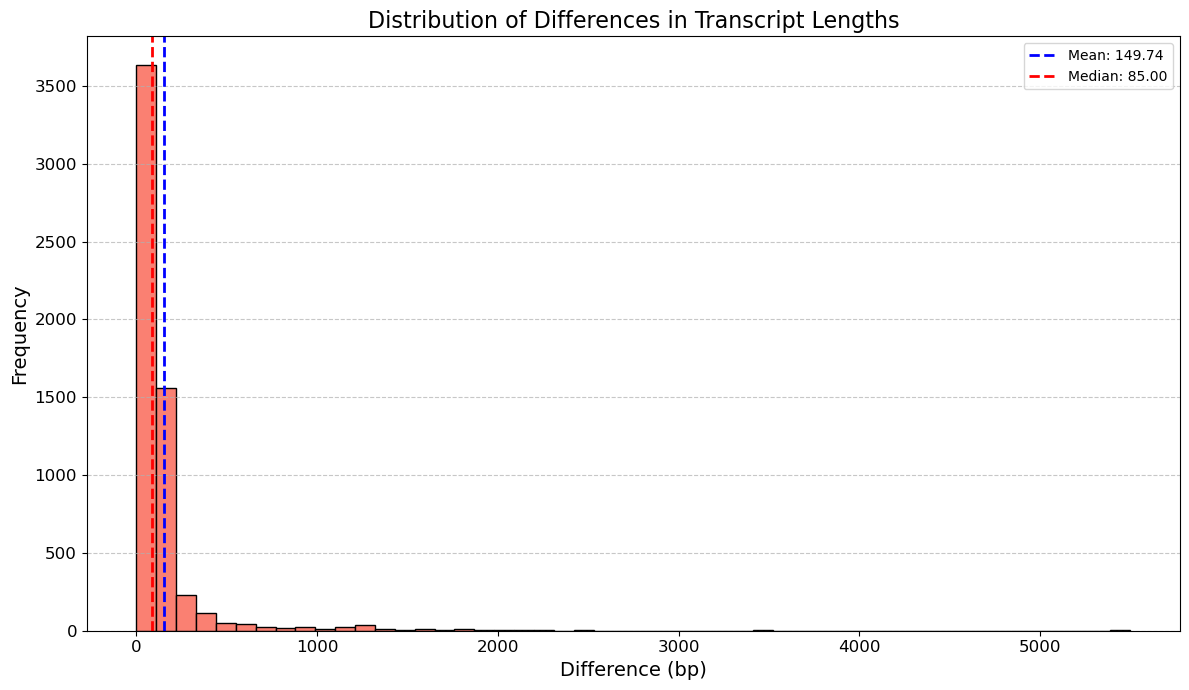

Number of unique genes in original gtf file: 6713
Unique gene IDs saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_genes_count_gff/unique_genes.csv


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Longest_isoform_length_vs_original/trim30_2_final_gene_length_differences_gtf_filtered.csv"
df = pd.read_csv(file_path)

# Count the number of unique genes
unique_gene_count = df['gene_id'].nunique()
print(f"Number of unique genes that have longest new transcript/isoform: {unique_gene_count}")

# Make all differences positive
differences = df['length_difference'].abs()

# Calculate statistics
mean_diff = differences.mean()
median_diff = differences.median()

# Create distribution plot
plt.figure(figsize=(12, 7))
plt.hist(differences, bins=50, edgecolor='black', color='salmon')
plt.title('Distribution of Differences in Transcript Lengths', fontsize=16)
plt.xlabel('Difference (bp)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add vertical lines for mean and median
plt.axvline(mean_diff, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_diff:.2f}')
plt.axvline(median_diff, color='red', linestyle='--', linewidth=2, label=f'Median: {median_diff:.2f}')

plt.legend()
plt.tight_layout()
plt.show()



## the unique genes in original gff file 

import pandas as pd
import re
import os

# Load the GFF file
file_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
df = pd.read_csv(file_path, sep='\t', comment='#', header=None)

# Extract the attribute column (usually column 9 in GFF, index 8 in pandas)
attributes = df[8]

# Use regex to extract gene_id values from the attributes
gene_ids = attributes.str.extract(r'gene_id=([^;]+)')[0]

# Drop missing values and count unique gene IDs
unique_gene_ids = gene_ids.dropna().unique()
unique_gene_count = len(unique_gene_ids)

print(f"Number of unique genes in original gtf file: {unique_gene_count}")

# 
output_folder = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_genes_count_gff"  
os.makedirs(output_folder, exist_ok=True)

# Save unique gene IDs to CSV in that folder
output_csv = os.path.join(output_folder, "unique_genes.csv")
unique_genes_df = pd.DataFrame(unique_gene_ids, columns=["gene_id"])
unique_genes_df.to_csv(output_csv, index=False)

print(f"Unique gene IDs saved to: {output_csv}")


## 4. Peaks Per Transcripts + Distribution of Transcripts per Gene
Analyzing how many new transcripts (derived from MACS2 peaks) are associated with each gene, and visualizing the distribution of transcripts per gene.

Total number of peaks (transcripts): 9425
Transcripts per gene written to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Peaks_per_gene/transcripts_per_gene.csv


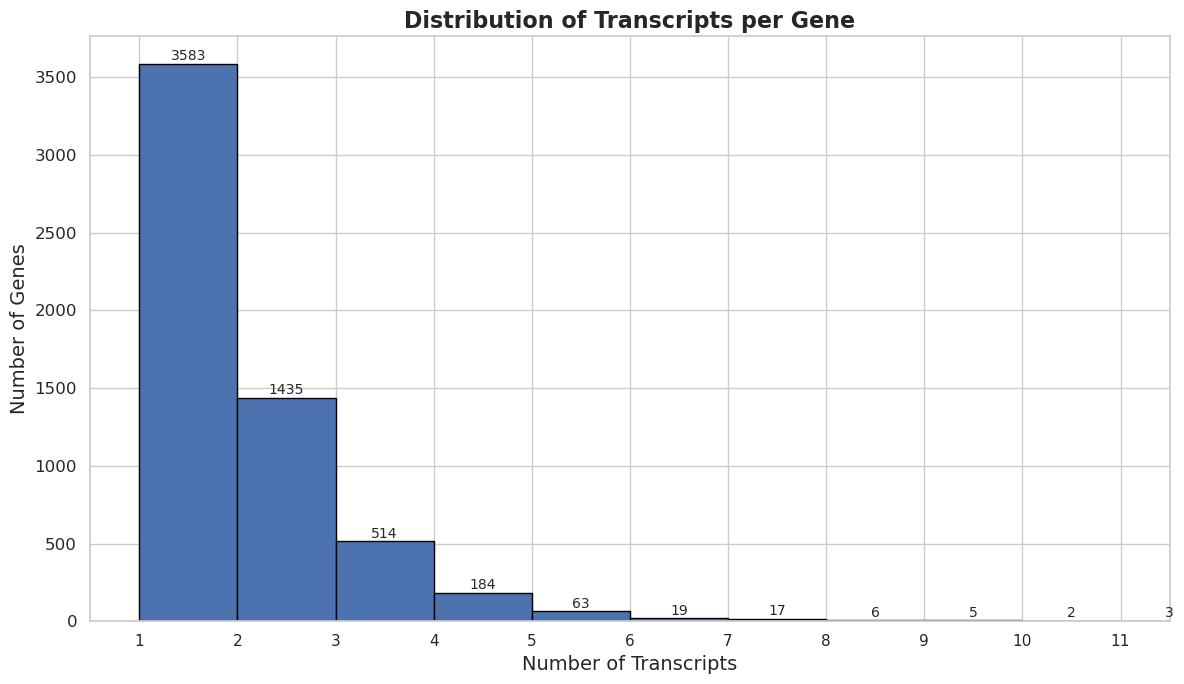

In [20]:
#### Peaks Per Transcripts ####


import pandas as pd
import re

# === Load the GTF file ===
gtf_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf"
gtf_df = pd.read_csv(gtf_path, sep="\t", comment='#', header=None)

# === Extract only transcript entries ===
transcript_df = gtf_df[gtf_df[2] == "transcript"].copy()

# === Extract gene_id using regex from the attributes column ===
transcript_df["gene_id"] = transcript_df[8].str.extract(r'gene_id "([^"]+)"')

# === Count number of transcripts per gene ===
transcripts_per_gene = transcript_df["gene_id"].value_counts().reset_index()
transcripts_per_gene.columns = ["gene_id", "transcript_count"]

# === Save output ===
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Peaks_per_gene/transcripts_per_gene.csv"
transcripts_per_gene.to_csv(output_path, index=False)

# === Total number of transcript entries (peaks) ===
total_peaks = transcript_df.shape[0]
print(f"Total number of peaks (transcripts): {total_peaks}")
print(f"Transcripts per gene written to: {output_path}")


#### Plot: Distribution of Transcripts per Gene ####

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load the data ===
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Peaks_per_gene/transcripts_per_gene.csv"
df = pd.read_csv(input_path)

# === Plot configuration ===
sns.set(style="whitegrid")
plt.figure(figsize=(12, 7))

# Define histogram bins
max_transcripts = df["transcript_count"].max()
bins = np.arange(1, max_transcripts + 2)

# Create histogram
counts, _, _ = plt.hist(df["transcript_count"], bins=bins, color="#4C72B0", edgecolor="black")

# Add X-axis ticks and limit
plt.xticks(bins[:-1])
plt.xlim(0.5, max_transcripts + 0.5)

# Labels and title
plt.title("Distribution of Transcripts per Gene", fontsize=16, weight='bold')
plt.xlabel("Number of Transcripts", fontsize=14)
plt.ylabel("Number of Genes", fontsize=14)
plt.yticks(fontsize=12)

# Annotate bars with counts
for i, count in enumerate(counts):
    if count > 0:
        plt.text(bins[i] + 0.5, count + 5, f"{int(count)}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 5. Finding ORFs

### 5.1 Extract uORF and CDS Entries from GTF
- Filter `Scer.translated.gPred.gtf` to retain only lines containing both `"uORF"` and `"CDS"`.

In [72]:
input_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/ncORFs/Scer.translated.gPred.gtf"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/Scer.uORF_CDS_only.gtf"

with open(input_path, "r") as infile, open(output_path, "w") as outfile:
    for line in infile:
        if line.startswith("#"):
            continue  
        if "uORF" in line and "CDS" in line:
            outfile.write(line)

print(f"Extracted GTF entries with both 'uORF' and 'CDS' in attributes saved to: {output_path}")


Extracted GTF entries with both 'uORF' and 'CDS' in attributes saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/Scer.uORF_CDS_only.gtf


### 5.2 Convert GTF Files to BED
- Convert the filtered uORF/CDS GTF and reconstructed transcript GTF files into BED format for use with BEDTools.

In [73]:
def gtf_to_bed(gtf_path, bed_path):
    with open(gtf_path) as infile, open(bed_path, 'w') as outfile:
        for line in infile:
            if line.startswith("#"):
                continue
            fields = line.strip().split('\t')
            if len(fields) < 9:
                continue
            chrom, _, _, start, end, _, strand, _, attributes = fields
            start = int(start) - 1  # Convert to 0-based for BED
            transcript_id = "NA"
            for field in attributes.strip().split(';'):
                field = field.strip()
                if field.startswith("transcript_id"):
                    transcript_id = field.split()[-1].replace('"', '').replace(';', '')
                    break
            outfile.write(f"{chrom}\t{start}\t{end}\t{transcript_id}\t.\t{strand}\n")

# === File paths ===
uorf_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/Scer.uORF_CDS_only.gtf"
uorf_bed = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/Scer.uORF_CDS_only_filtered.bed"

transcripts_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf"
transcripts_bed = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/trim30_2_reconstructed_transcripts.bed"

# === Convert both ===
gtf_to_bed(uorf_gtf, uorf_bed)
print(f"Converted uORF GTF to BED: {uorf_bed}")

gtf_to_bed(transcripts_gtf, transcripts_bed)
print(f"Converted transcripts GTF to BED: {transcripts_bed}")


Converted uORF GTF to BED: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/Scer.uORF_CDS_only_filtered.bed
Converted transcripts GTF to BED: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/trim30_2_reconstructed_transcripts.bed


### 5.3 Intersect uORFs with Reconstructed Transcripts
- Use `bedtools intersect` to identify overlaps between translated uORFs and the new reconstructed transcripts (from MACS2 peaks).


In [74]:
%%bash

module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/Scer.uORF_CDS_only_filtered.bed \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/trim30_2_reconstructed_transcripts.bed \
  -wa -wb -s \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/intersected_uORF_transcripts.bed

echo "BEDTools intersect completed successfully."


BEDTools intersect completed successfully.


### 5.4 Count uORF Overlaps per Transcript
- Count how many uORFs overlap each transcript.
- Report total overlaps and number of unique genes affected.
- Save counts to CSV.

In [75]:
import pandas as pd

# === Load the intersected BED output ===
input_bed = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/intersected_uORF_transcripts.bed"
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/all_new_transcripts_translated_reconstructed_overlap_counts.csv"

# BEDTools -wa -wb output → 6 columns from each file
df = pd.read_csv(input_bed, sep="\t", header=None)

# Assign column names
df.columns = [
    "chr_uorf", "start_uorf", "end_uorf", "uorf_id", "score_uorf", "strand_uorf",
    "chr_tx", "start_tx", "end_tx", "transcript_id", "score_tx", "strand_tx"
]

# Count how many uORFs each transcript overlaps
transcript_counts = df["transcript_id"].value_counts().reset_index()
transcript_counts.columns = ["transcript_id", "uORF_overlap_count"]

# Save to CSV
transcript_counts.to_csv(output_csv, index=False)
print(f"Saved overlap counts to: {output_csv}")


#### Total uORF_overlap_count (sum of overlaps across all transcripts) ####
#### Number of unique genes (based on transcript_id) ####

import pandas as pd

# === Load transcript-level uORF overlap counts ===
input_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/all_new_transcripts_translated_reconstructed_overlap_counts.csv"
df = pd.read_csv(input_csv)

# Total number of uORF overlaps (sum of counts)
total_uorf_overlaps = df["uORF_overlap_count"].sum()
print(f"Total uORF overlaps: {total_uorf_overlaps}")

# Extract gene ID from transcript ID (before first underscore)
df["gene_id"] = df["transcript_id"].str.extract(r"^([^_]+)")

# Count number of unique gene IDs
unique_genes = df["gene_id"].nunique()
print(f"Number of unique genes with translated uORFs: {unique_genes}")




Saved overlap counts to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/all_new_transcripts_translated_reconstructed_overlap_counts.csv
Total uORF overlaps: 4052
Number of unique genes with translated uORFs: 1508


###  include transcripts that do not overlap any uORF in your output.

In [300]:
%%bash

module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/trim30_2_reconstructed_transcripts.bed \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/Scer.uORF_CDS_only_filtered.bed \
  -loj -s \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/intersected_uORF_transcripts_LOJ.bed


In [301]:
import pandas as pd

# Load LOJ output
loj_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/intersected_uORF_transcripts_LOJ.bed"
df = pd.read_csv(loj_path, sep="\t", header=None)

# Columns: transcript (A) + uORF (B)
df.columns = [
    "chr_tx", "start_tx", "end_tx", "transcript_id", "score_tx", "strand_tx",
    "chr_uorf", "start_uorf", "end_uorf", "uorf_id", "score_uorf", "strand_uorf"
]

# If no overlap, uorf_id will be '.' or NaN — so count non-null rows per transcript
df["has_uorf"] = df["uorf_id"].notna() & (df["uorf_id"] != ".")

# Count uORF overlaps per transcript
overlap_counts = df.groupby("transcript_id")["has_uorf"].sum().reset_index()
overlap_counts.columns = ["transcript_id", "uORF_overlap_count"]

# Save result
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/all_transcripts_with_uorf_overlap_counts.csv"
overlap_counts.to_csv(output_csv, index=False)

print(f"Saved overlap counts (including 0s) to: {output_csv}")


Saved overlap counts (including 0s) to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/all_transcripts_with_uorf_overlap_counts.csv


### 5.5 Count Unique Genes with uORFs (From Original GTF)
- From the original `Scer.translated.gPred.gtf`, count how many **unique genes** have associated uORFs.


In [82]:
import pandas as pd

#  File paths 
gtf_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/ncORFs/Scer.translated.gPred.gtf"
output_all_uorf_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/all_uorf_entries.csv"
output_unique_genes_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/unique_uorf_genes.csv"

#  Load the GTF file 
df = pd.read_csv(gtf_path, sep="\t", comment="#", header=None)

#  Filter rows containing '|uORF|' 
df_uorf = df[df[8].str.contains(r"\|uORF\|", regex=True, na=False)].copy()

# Save all filtered entries
df_uorf.to_csv(output_all_uorf_csv, sep="\t", header=False, index=False)
print(f"All '|uORF|' entries saved to: {output_all_uorf_csv}")

#  Extract gene names from gene_id 
df_uorf["gene_name"] = df_uorf[8].str.extract(r'^gene_id "([^\.]+)')

#  Get unique gene names 
unique_genes = df_uorf["gene_name"].dropna().unique()

# Save unique gene names to CSV 
pd.DataFrame(unique_genes, columns=["gene_name"]).to_csv(output_unique_genes_csv, index=False)
print(f"Number of unique genes with '|uORF|': {len(unique_genes)}")
print(f"Gene list saved to: {output_unique_genes_csv}")


All '|uORF|' entries saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/all_uorf_entries.csv
Number of unique genes with '|uORF|': 1470
Gene list saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/unique_uorf_genes.csv


### 5.6 Trying to find an answer for this Q: How Many New Transcripts (Excl. Longest) Overlap ORFs?


#### 5.6.1 Extract Non-Longest Transcripts
- Remove the longest isoform per gene to isolate other transcript variants.

In [83]:
import pandas as pd

def parse_gtf(file_path):
    entries = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split('\t')
            if len(parts) != 9 or parts[2] != "transcript":
                continue
            seq_id, source, feature_type, start, end, score, strand, phase, attributes = parts
            attr_dict = {}
            for attr in attributes.strip().split(';'):
                if ' ' in attr:
                    key, value = attr.strip().split(' ', 1)
                    attr_dict[key.strip()] = value.strip().strip('"')
            transcript_id = attr_dict.get('transcript_id', '')
            gene_id = attr_dict.get('gene_id', transcript_id.split('_')[0])
            entries.append({
                "line": line.strip(),
                "seq_id": seq_id,
                "start": int(start),
                "end": int(end),
                "length": int(end) - int(start),
                "strand": strand,
                "transcript_id": transcript_id,
                "gene_id": gene_id
            })
    return pd.DataFrame(entries)

# Paths
input_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf"
output_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_nonlongest_isoforms.gtf"

# Parse GTF
df = parse_gtf(input_gtf)

# Find the longest transcript per gene
longest_per_gene = (
    df.sort_values(by="length", ascending=False)
      .drop_duplicates(subset="gene_id")
)

# Remove longest isoforms from full set
non_longest = df[~df["transcript_id"].isin(longest_per_gene["transcript_id"])]

# Write to file
with open(output_gtf, "w") as f:
    for line in non_longest["line"]:
        f.write(line + "\n")

print(f"Non-longest isoforms saved to: {output_gtf}")


Non-longest isoforms saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_nonlongest_isoforms.gtf


#### 5.6.2 Convert Non-Longest Transcripts to BED
- Convert filtered non-longest GTF to BED format.

In [84]:
# Path to your non-longest transcript GTF (generated previously)
nonlongest_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_nonlongest_isoforms.gtf"
nonlongest_bed = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/trim30_2_nonlongest_isoforms.bed"

# Convert non-longest GTF to BED
gtf_to_bed(nonlongest_gtf, nonlongest_bed)
print(f"Converted non-longest transcripts GTF to BED: {nonlongest_bed}")


Converted non-longest transcripts GTF to BED: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/trim30_2_nonlongest_isoforms.bed


#### 5.6.3 Intersect Non-Longest Transcripts with uORFs
- Run `bedtools intersect` to find overlaps between non-longest transcripts and uORFs.


In [85]:
%%bash

module load BEDTools/2.31.1-GCC-13.3.0

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/Scer.uORF_CDS_only_filtered.bed \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/trim30_2_nonlongest_isoforms.bed \
  -wa -wb \
  -s \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/intersected_uORF_nonlongest_transcripts.bed

echo "BEDTools intersect completed successfully."


BEDTools intersect completed successfully.


#### 5.6.4 Count Overlaps for Non-Longest Isoforms
- Count overlaps, extract `gene_id`, and report:
  - Total uORF overlaps
  - Unique genes with uORF overlap
- Save transcript-level counts to CSV.

In [2]:
import pandas as pd

#  File paths 
input_bed = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/intersected_uORF_nonlongest_transcripts.bed"
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/doublecheck_translated_nonlongest_overlap_counts.csv"

#  Load BEDTools intersect result 
df = pd.read_csv(input_bed, sep="\t", header=None)

# Assign column names
df.columns = [
    "chr_uorf", "start_uorf", "end_uorf", "uorf_id", "score_uorf", "strand_uorf",
    "chr_tx", "start_tx", "end_tx", "transcript_id", "score_tx", "strand_tx"
]

#  Count overlaps per transcript 
transcript_counts = df["transcript_id"].value_counts().reset_index()
transcript_counts.columns = ["transcript_id", "uORF_overlap_count"]


#  Extract gene ID from transcript ID (before first underscore)
transcript_counts["gene_id"] = transcript_counts["transcript_id"].str.extract(r"^([^_]+)")

#  Summary stats 
total_uorf_overlaps = transcript_counts["uORF_overlap_count"].sum()
unique_transcripts = transcript_counts["transcript_id"].nunique()
unique_genes = transcript_counts["gene_id"].nunique()

#  Output 
transcript_counts.to_csv(output_csv, index=False)

#  Report 
print(f"Total uORF overlaps (non-longest transcripts): {total_uorf_overlaps}")
print(f"Total New Transcripts (Excl. Longest) Overlap ORFs): {unique_transcripts}")
print(f"Unique genes with translated uORFs (non-longest isoforms): {unique_genes}")
print(f"Output saved to: {output_csv}")


Total uORF overlaps (non-longest transcripts): 1812
Total New Transcripts (Excl. Longest) Overlap ORFs): 1075
Unique genes with translated uORFs (non-longest isoforms): 674
Output saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/doublecheck_translated_nonlongest_overlap_counts.csv


### 5.7 Size Comparison: Non-Longest Transcripts vs. Original Genes
#### 5.7.1 Compute Transcript Lengths (Excl. Longest)
- Calculate the length of each non-longest transcript.

In [87]:
import pandas as pd
import re

# === File paths ===
gtf_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_nonlongest_isoforms.gtf"
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/doublecheck_nonlongest_transcript_lengths.csv"

# === Load GTF and filter transcripts ===
df = pd.read_csv(gtf_path, sep="\t", comment="#", header=None,
                 names=["seqid", "source", "feature", "start", "end", "score", "strand", "phase", "attributes"])
transcripts = df[df["feature"] == "transcript"].copy()

# === Extract transcript ID ===
def extract_transcript_id(attr_str):
    match = re.search(r'transcript_id "([^"]+)"', attr_str)
    return match.group(1) if match else "NA"

transcripts["transcript_id"] = transcripts["attributes"].apply(extract_transcript_id)

# === Calculate transcript length ===
transcripts["length"] = transcripts["end"] - transcripts["start"] + 1

# === Keep only relevant columns and save ===
length_df = transcripts[["transcript_id", "length"]].copy()
length_df.to_csv(output_csv, index=False)

print(f"Transcript lengths saved to: {output_csv}")







Transcript lengths saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/doublecheck_nonlongest_transcript_lengths.csv


#### 5.7.2 Compute Gene Lengths from Original GFF
- Extract and compute gene lengths from the original annotation.

In [88]:
import pandas as pd

# === File paths ===
gff_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/original_lengths_gene_from_gff.csv"

# === Load the GFF file ===
gff_df = pd.read_csv(
    gff_path, sep='\t', comment='#', header=None,
    names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"]
)

# === Extract gene_id from the attributes column ===
gff_df["gene_id"] = gff_df["attributes"].str.extract(r'gene_id=([^;]+)')

# === Filter for gene features ===
genes = gff_df[gff_df["type"] == "gene"].copy()

# === Compute gene length ===
genes["gene_length"] = genes["end"] - genes["start"] + 1

# === Keep only necessary columns ===
gene_lengths = genes[["gene_id", "gene_length"]]

# === Save to CSV ===
gene_lengths.to_csv(output_csv, index=False)
print(f"Gene lengths saved to: {output_csv}")


Gene lengths saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/original_lengths_gene_from_gff.csv


#### 5.7.3 Compare Transcript Lengths as % of Gene Length
- Merge transcript and gene length data.
- Compute % coverage of each gene by its non-longest transcript.
- Save to CSV and visualize with:
  - Violin plot
  - Histogram 

✅ CSV saved: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/transcript_length_percentage_vs_gene.csv


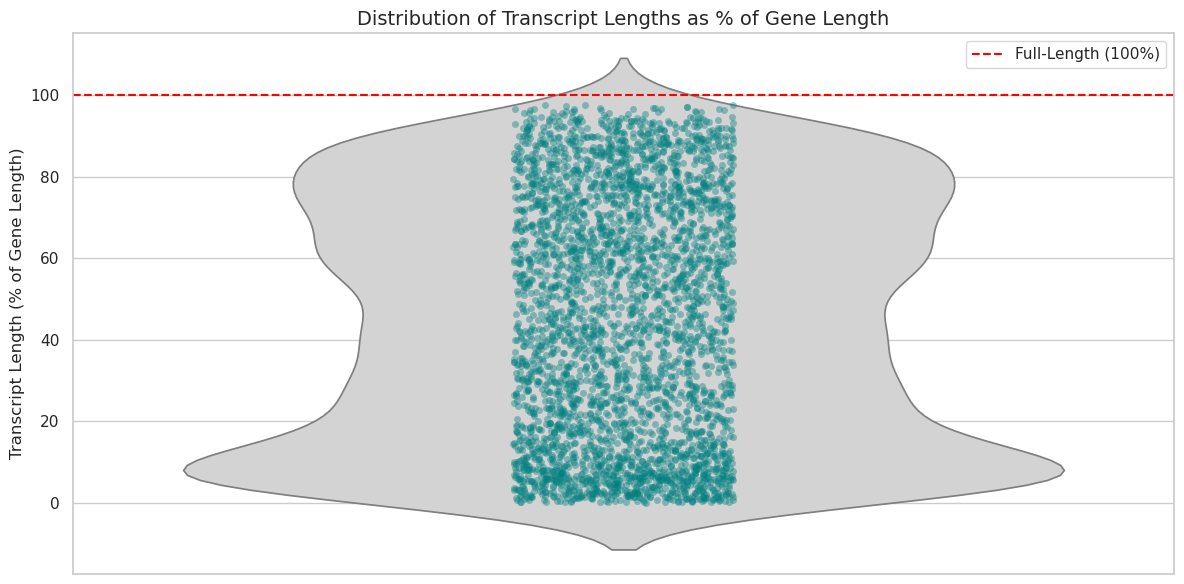

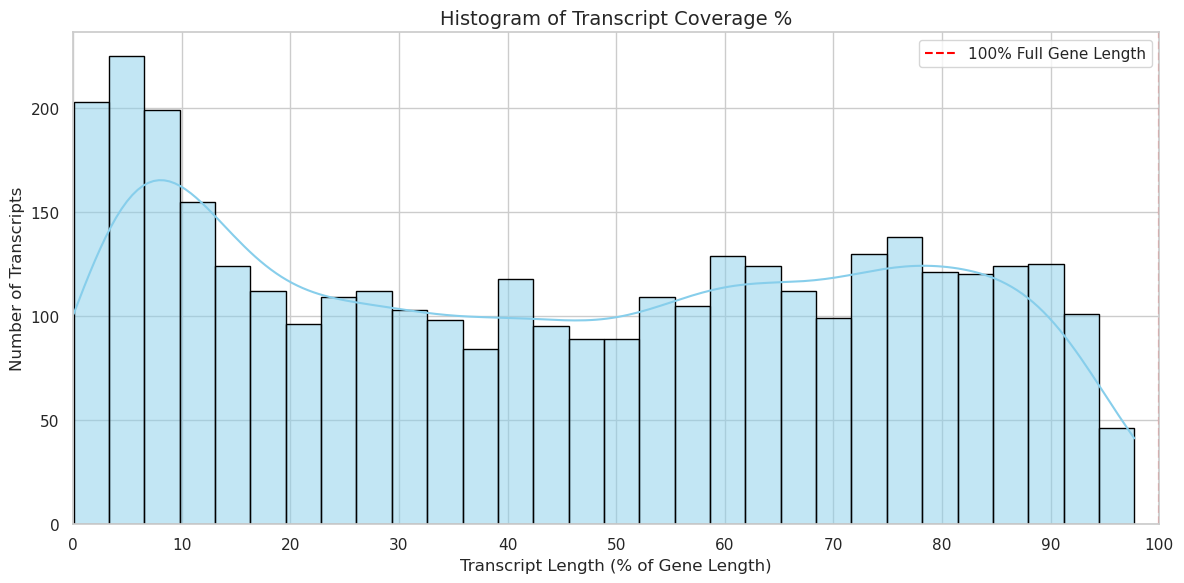

In [89]:
import pandas as pd

# === File paths ===
transcript_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/doublecheck_nonlongest_transcript_lengths.csv"
gene_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/original_lengths_gene_from_gff.csv"
output_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/BEDTools_intersect_and_uORFs/transcript_length_percentage_vs_gene.csv"

# === Load Data ===
transcripts_df = pd.read_csv(transcript_file)
genes_df = pd.read_csv(gene_file)

# === Standardize column names ===
transcripts_df.rename(columns={"length": "transcript_length"}, inplace=True)
genes_df.rename(columns={"length": "gene_length"}, inplace=True)

# === Extract gene_id from transcript_id (e.g., YDL134C_last30_2_peak_1041 → YDL134C) ===
transcripts_df["gene_id"] = transcripts_df["transcript_id"].str.extract(r'^([^_]+)')

# === Merge on gene_id ===
merged_df = pd.merge(transcripts_df, genes_df, on="gene_id", how="inner")

# === Calculate percentage length ===
merged_df["length_percentage"] = (merged_df["transcript_length"] / merged_df["gene_length"]) * 100

# === Save to CSV ===
merged_df.to_csv(output_file, index=False)
print(f"CSV saved: {output_file}")

# === Optional preview ===
#print(merged_df.head())


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.violinplot(data=merged_df, y="length_percentage", inner=None, color="lightgray")
sns.stripplot(data=merged_df, y="length_percentage", color="teal", alpha=0.4, jitter=True)

plt.title("Distribution of Transcript Lengths as % of Gene Length", fontsize=14)
plt.ylabel("Transcript Length (% of Gene Length)")
plt.axhline(100, color="red", linestyle="--", label="Full-Length (100%)")
plt.legend()
plt.tight_layout()
plt.show()



import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(merged_df["length_percentage"], bins=30, kde=True, color="skyblue", edgecolor="black")

# Improve x-axis
plt.xticks(range(0, 110, 10))  # Ticks from 0 to 100 with step of 10
plt.xlim(0, 100)               # Limit range to 0–100%
plt.axvline(100, color="red", linestyle="--", label="100% Full Gene Length")

# Labels and layout
plt.title("Histogram of Transcript Coverage %", fontsize=14)
plt.xlabel("Transcript Length (% of Gene Length)")
plt.ylabel("Number of Transcripts")
plt.legend()
plt.tight_layout()
plt.show()



# 6. Quantification + Statistics 

### 6.1 New Transcripts/Isoforms Overlapping with Original CDS

In this section, we investigate whether the newly identified transcripts (including the longest isoforms) overlap with the coding sequence (CDS) regions of the original transcripts. 

Specifically, we aim to determine:
- Which new transcripts fall within the CDS boundaries of the original annotations.
- What percentage of each new transcript overlaps with the corresponding original CDS.


#### 6.1.1 Extract the CDS from Scer.utr.agat.gff

In [94]:
import pandas as pd

# === File paths ===
input_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/Annotation/Scer.utr.agat.gff"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/new_annotation/Scer.utr.CDS_only.gff"

# === Load the GFF file ===
gff = pd.read_csv(input_path, sep="\t", comment="#", header=None)

# === Filter only CDS rows ===
cds_df = gff[gff[2] == "CDS"]

# === Save to a new GFF file ===
cds_df.to_csv(output_path, sep="\t", header=False, index=False)

print(f"Extracted CDS entries saved to: {output_path}")


Extracted CDS entries saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/new_annotation/Scer.utr.CDS_only.gff


#### 6.1.2 Convert the the annotation files to bed files

In [95]:
import pandas as pd
import re

# === File paths ===
gtf_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf"
cds_gff_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/new_annotation/Scer.utr.CDS_only.gff"
gtf_bed = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/for_cds_narrowpeak_transcripts_trim30_2.bed"
cds_bed = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/Scer.utr.CDS_only.bed"

# === Convert GTF to BED ===
gtf_df = pd.read_csv(gtf_path, sep="\t", comment='#', header=None,
    names=["seqid", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"])
gtf_df = gtf_df[gtf_df["feature"] == "transcript"].copy()
gtf_df["transcript_id"] = gtf_df["attribute"].str.extract(r'transcript_id "([^"]+)"')

# Convert to BED format
gtf_df["start_bed"] = gtf_df["start"] - 1  # 0-based
gtf_bed_df = gtf_df[["seqid", "start_bed", "end", "transcript_id", "score", "strand"]].fillna(".")

# Save BED
gtf_bed_df.to_csv(gtf_bed, sep="\t", header=False, index=False)

# === Convert CDS GFF to BED ===
cds_df = pd.read_csv(cds_gff_path, sep="\t", comment='#', header=None,
    names=["seqid", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"])
cds_df = cds_df[cds_df["feature"] == "CDS"].copy()
cds_df["cds_id"] = cds_df["attribute"].str.extract(r'gene_id=([^;]+)')
cds_df["start_bed"] = cds_df["start"] - 1
cds_bed_df = cds_df[["seqid", "start_bed", "end", "cds_id", "score", "strand"]].fillna(".")

# Save BED
cds_bed_df.to_csv(cds_bed, sep="\t", header=False, index=False)

print("GTF and CDS GFF successfully converted to BED.")


GTF and CDS GFF successfully converted to BED.


#### 6.1.3 BEDtools intersect

In [97]:
%%bash

module load BEDTools/2.31.1-GCC-13.3.0

# === File paths ===
cds_bed="/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/Scer.utr.CDS_only.bed"
transcripts_bed="/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/for_cds_narrowpeak_transcripts_trim30_2.bed"
output_dir="/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics"

#  1. Get overlapping transcripts with CDS and count overlapping nucleotides 
bedtools intersect \
  -a "$cds_bed" \
  -b "$transcripts_bed" \
  -s -wo \
  > "$output_dir/overlaps_transcript_cds_with_overlap_nt.bed"

#  2. Get non-overlapping transcripts 
bedtools intersect \
  -a "$transcripts_bed" \
  -b "$cds_bed" \
  -s -v \
  > "$output_dir/non_overlapping_transcripts.bed"

echo "Finished: Overlapping and non-overlapping transcripts extracted."


Finished: Overlapping and non-overlapping transcripts extracted.


#### Filter the BED file to retain only transcripts that are derived from their annotated parent genes.

In [100]:
import pandas as pd

# === Load the BED file ===
input_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlaps_transcript_cds_with_overlap_nt.bed"
output_file = "//home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/filtered_transcript_cds_overlap.bed"

# No headers in BED, so specify them
cols = [
    "cds_chr", "cds_start", "cds_end", "gene_id", "cds_score", "cds_strand",
    "tx_chr", "tx_start", "tx_end", "transcript_id", "tx_score", "tx_strand",
    "overlap_nt"
]

df = pd.read_csv(input_file, sep="\t", header=None, names=cols)

# === Extract gene name from transcript_id by splitting at the first underscore ===
df["tx_gene"] = df["transcript_id"].str.split("_", n=1).str[0]

# === Keep only rows where gene_id matches tx_gene ===
df_filtered = df[df["gene_id"] == df["tx_gene"]]

# === Save the filtered output ===
df_filtered.to_csv(output_file, sep="\t", header=False, index=False)

print(f"Filtered file saved: {output_file}")
print(f"Kept {len(df_filtered)} out of {len(df)} rows.")




Filtered file saved: //home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/filtered_transcript_cds_overlap.bed
Kept 8887 out of 9347 rows.


#### Treat overlapping with two CDS regions of the same gene as a single overlap for the transcript.

In [101]:
import pandas as pd

# === Load your overlap file ===
input_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/filtered_transcript_cds_overlap.bed"
output_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/merged_overlap_counts.bed"

# Define column names (modify if your file structure differs)
cols = [
    "cds_chr", "cds_start", "cds_end", "gene_id", "cds_score", "cds_strand",
    "tx_chr", "tx_start", "tx_end", "transcript_id", "tx_score", "tx_strand",
    "overlap_nt", "gene_match"
]

# Read the file
df = pd.read_csv(input_file, sep="\t", header=None, names=cols)

# === Group by gene_id and transcript_id, and sum the overlaps ===
df_grouped = df.groupby(["gene_id", "transcript_id"], as_index=False)["overlap_nt"].sum()

# === Optional: sort by gene or overlap size ===
df_grouped = df_grouped.sort_values(by=["gene_id", "overlap_nt"], ascending=[True, False])

# === Save result ===
df_grouped.to_csv(output_file, sep="\t", header=True, index=False)

print(f"Saved grouped overlaps to: {output_file}")


Saved grouped overlaps to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/merged_overlap_counts.bed


#### calculate the total CDS length

In [107]:
import pandas as pd

# Input and Output File Paths
input_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/filtered_transcript_cds_overlap.bed"  
output_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/cds_length_per_transcript.csv"

# Define columns based on your example format
cols = [
    "cds_chr", "cds_start", "cds_end", "gene_id", "cds_score", "cds_strand",
    "tx_chr", "tx_start", "tx_end", "transcript_id", "tx_score", "tx_strand",
    "overlap_nt", "gene_match"
]

# Load the data
df = pd.read_csv(input_file, sep="\t", header=None, names=cols)

# Calculate CDS length per row (inclusive range)
df["cds_length"] = df["cds_end"] - df["cds_start"]

# Sum CDS length per transcript
cds_length_per_transcript = df.groupby("transcript_id")["cds_length"].sum().reset_index()

# Save to CSV
cds_length_per_transcript.to_csv(output_file, index=False)

print(f"CDS lengths per transcript saved to: {output_file}")



CDS lengths per transcript saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/cds_length_per_transcript.csv


#### making csv file: summary 

In [118]:
import pandas as pd

# === File paths ===
merged_overlap_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/merged_overlap_counts.bed"  
non_overlap_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/non_overlapping_transcripts.bed"  
output_csv_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary.csv"

# === Load merged overlaps ===
# Expected columns: gene_id, transcript_id, overlap_nt
df_overlap = pd.read_csv(merged_overlap_path, sep="\t")

# === Load non-overlapping transcripts ===
# Expected BED columns: chr, start, end, transcript_id, score, strand
df_non_overlap = pd.read_csv(non_overlap_path, sep="\t", header=None)
df_non_overlap.columns = ["chr", "start", "end", "transcript_id", "score", "strand"]

# === Extract gene_id from transcript_id (part before first underscore) ===
df_non_overlap["gene_id"] = df_non_overlap["transcript_id"].str.split("_", n=1).str[0]

# === Create DataFrame with overlap_nt = 0 ===
df_non_overlap_final = df_non_overlap[["gene_id", "transcript_id"]].copy()
df_non_overlap_final["overlap_nt"] = 0

# === Combine both DataFrames ===
df_combined = pd.concat([df_overlap, df_non_overlap_final], ignore_index=True)

# === Save to CSV ===
df_combined.to_csv(output_csv_path, index=False)

print(f"Combined overlap summary saved to: {output_csv_path}")


Combined overlap summary saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary.csv


#### add the cds length to the summary file 

In [119]:
import pandas as pd

# === File Paths ===
summary_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary.csv"  
cds_length_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/cds_length_per_transcript.csv"  

# === Load files ===
df_summary = pd.read_csv(summary_path)
df_cds_length = pd.read_csv(cds_length_path)

# === Merge CDS lengths into the summary ===
df_summary = pd.merge(df_summary, df_cds_length, on="transcript_id", how="left")

# === Overwrite the existing summary file ===
df_summary.to_csv(summary_path, index=False)

print(f"CDS lengths successfully added to existing summary file: {summary_path}")


CDS lengths successfully added to existing summary file: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary.csv


#### overlap %

In [120]:
import pandas as pd

# === Input and Output File ===
input_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary.csv"  


# === Load the summary data ===
df = pd.read_csv(input_csv)

# === Calculate percent overlap ===
df["overlap_pct"] = (df["overlap_nt"] / df["cds_length"]) * 100

# === Save back to the same file (overwrite) ===
df.to_csv(input_csv, index=False)

# === Optional: save to a different file ===
# df.to_csv(output_csv, index=False)

print(f"Percent overlap added to: {input_csv}")


Percent overlap added to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary.csv


#### 6.1.4 Analyze the number and percentage of overlaps — i.e., what proportion of each new transcript overlaps with the original CDS

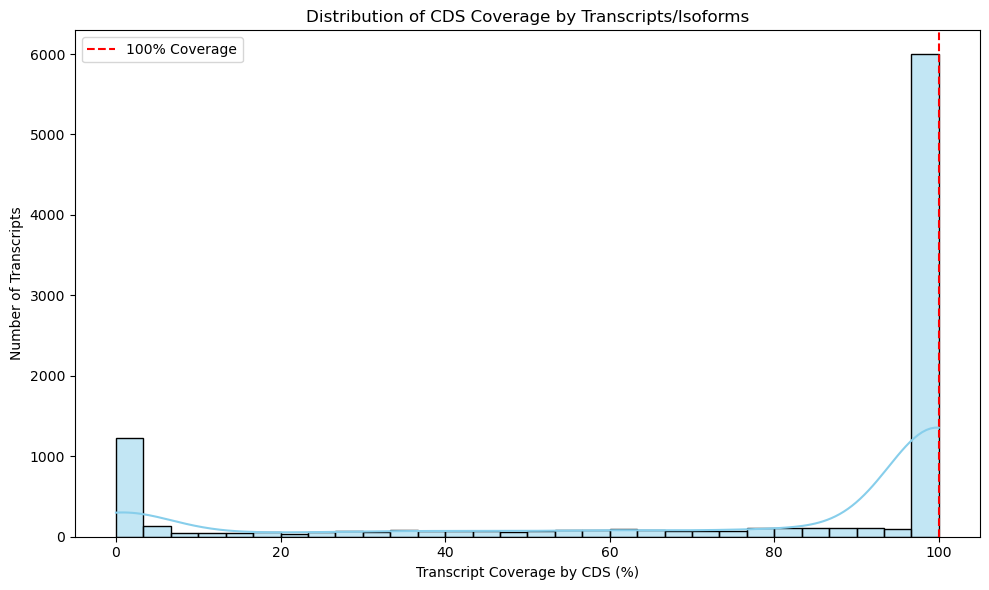

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the summary with overlap percentage
summary_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_polya_stats_without_0_-1.csv"
df = pd.read_csv(summary_path)

# Plot histogram of percent overlap
plt.figure(figsize=(10, 6))
sns.histplot(df["overlap_pct"], bins=30, kde=True, color="skyblue", edgecolor="black")
plt.axvline(100, color="red", linestyle="--", label="100% Coverage")
plt.xlabel("Transcript Coverage by CDS (%)")
plt.ylabel("Number of Transcripts")
plt.title("Distribution of CDS Coverage by Transcripts/Isoforms")
plt.legend()
plt.tight_layout()
plt.show()






#### 6.1.5 Add a flag indicating whether the transcript is the longest isoform

In [128]:
import pandas as pd

# === File paths ===
overlap_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary.csv"
longest_gtf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_longest_annotation.gtf"
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary_cds_transcript_overlap_percent_FLAGGED_FIXED.csv"

# === Step 1: Load summary/overlap data ===
overlap_df = pd.read_csv(overlap_csv)
overlap_df["transcript_id"] = overlap_df["transcript_id"].astype(str).str.strip()

# === Step 2: Load GTF and extract transcript_id ===
gtf_df = pd.read_csv(longest_gtf, sep="\t", comment="#", header=None)

# Extract transcript_id from attributes column (usually column 8)
# Adjust if it's in a different column
gtf_df["transcript_id"] = gtf_df[8].astype(str).str.extract(r'transcript_id[ ="]*([^";]+)')

# === Step 3: Build set of longest transcript IDs ===
longest_ids = set(gtf_df["transcript_id"].dropna().unique())

# === Step 4: Flag overlap rows ===
overlap_df["is_longest"] = overlap_df["transcript_id"].isin(longest_ids)

# === Step 5: Save result ===
overlap_df.to_csv(output_csv, index=False)
print(f"Summary file with 'is_longest' flag saved to:\n{output_csv}")


Summary file with 'is_longest' flag saved to:
/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary_cds_transcript_overlap_percent_FLAGGED_FIXED.csv


#### Add the length of each new transcript/isoform to the summary file 

In [131]:
import pandas as pd
import re

# === File paths ===
summary_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary_cds_transcript_overlap_percent_FLAGGED_FIXED.csv"
gtf_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_transcript_length_strand.csv"

# === Load summary file and GTF ===
summary_df = pd.read_csv(summary_path)
gtf_df = pd.read_csv(gtf_path, sep="\t", comment='#', header=None)

# === Filter GTF for transcript entries only ===
gtf_df = gtf_df[gtf_df[2] == "transcript"].copy()

# === Extract transcript_id from attributes ===
gtf_df["transcript_id"] = gtf_df[8].str.extract(r'transcript_id "([^"]+)"')

# === Calculate transcript length and extract strand ===
gtf_df["transcript_length"] = gtf_df[4] - gtf_df[3] + 1
gtf_df["transcript_strand"] = gtf_df[6]

# === Build minimal DataFrame for merging ===
lengths_strands = gtf_df[["transcript_id", "transcript_length", "transcript_strand"]]

# === Merge into summary ===
merged_df = summary_df.merge(lengths_strands, on="transcript_id", how="left")

# === Save output ===
merged_df.to_csv(output_path, index=False)
print(f"summary1 saved to: {output_path}")


summary1 saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_transcript_length_strand.csv


### 6.2 strand-aware quantification of narrowPeak-defined regions

#### 6.2.1 Extend Peaks to Both Strands
Duplicate each peak from the original .narrowPeak file to create two versions: one assuming + strand and one - strand. This is necessary because narrowPeak files often lack strand information, but strand-specific counting tools (like featureCounts -s 1) require it.

In [132]:
import pandas as pd

# === File paths ===
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/last30_2_peaks.narrowPeak"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands.narrowPeak"

# === Load narrowPeak file ===
# narrowPeak has 10 standard columns; column 5 is strand (we'll overwrite it)
peaks_df = pd.read_csv(input_path, sep="\t", header=None)

# === Duplicate peaks with strand set to "+" and "-"
peaks_plus = peaks_df.copy()
peaks_minus = peaks_df.copy()

peaks_plus[5] = "+"
peaks_minus[5] = "-"

# === Combine both strand entries
extended_df = pd.concat([peaks_plus, peaks_minus], ignore_index=True)

# === Save to file
extended_df.to_csv(output_path, sep="\t", header=False, index=False)
print(f"Peaks with both strand orientations saved to: {output_path}")


Peaks with both strand orientations saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands.narrowPeak


#### 6.2.2 Convert Peaks to SAF Format
Transform the strand-duplicated .narrowPeak file into SAF (Simplified Annotation Format) for compatibility with featureCounts.

In [133]:
import pandas as pd

# Input narrowPeak file
peaks_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands.narrowPeak"
saf_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands.saf"

# Load narrowPeak
df = pd.read_csv(peaks_file, sep="\t", header=None)

# Build SAF format
# SAF: GeneID, Chr, Start, End, Strand
df_saf = pd.DataFrame({
    "GeneID": df[3],         # peak name
    "Chr": df[0],
    "Start": df[1] + 1,      # SAF uses 1-based start
    "End": df[2],
    "Strand": df[5]
})

# Save SAF
df_saf.to_csv(saf_file, sep="\t", index=False)
print(f"SAF file created at: {saf_file}")


SAF file created at: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands.saf


#### 6.2.3 Run featureCounts with Stranded Mode (1st Pass)

Ran featureCounts in stranded mode (-s 1) using the SAF file above.
Count reads overlapping each peak using the -s 1 option (stranded), creating strand-specific read counts for each duplicated peak.

In [134]:
%%bash

# Activate environment
source /home/saif/anaconda3/bin/activate featurecounts

# Run featureCounts
featureCounts \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands.saf \
  -F SAF \
  -o /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/featureCounts/read_counts_per_peak.txt \
  -T 20 \
  -s 1 \
  /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam



        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o output_reverseCorrected_last30_sorted.bam      ||
||                                                                            ||
||             Output file : read_counts_per_peak.txt                         ||
||                 Summary : read_counts_per_peak.txt.summary    

the names of the gene_id so we can get the counts per strand

#### 6.2.4 Disambiguate Peak IDs  + run featureCounts again 
After counting, modify the GeneIDs in the SAF file to explicitly tag them as **_positive** or **_negative**, making it easy to interpret counts.

In [135]:

import pandas as pd

# === File paths ===
input_saf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands.saf"
output_saf = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands_stranded_ids.saf"

# === Load SAF file ===
saf_df = pd.read_csv(input_saf, sep="\t")

# === Modify GeneID based on strand
saf_df["GeneID"] = saf_df.apply(
    lambda row: f"{row['GeneID']}_positive" if row["Strand"] == "+"
    else f"{row['GeneID']}_negative" if row["Strand"] == "-"
    else row["GeneID"],
    axis=1
)

# === Save updated SAF
saf_df.to_csv(output_saf, sep="\t", index=False)
print(f"Stranded SAF file saved to: {output_saf}")


Stranded SAF file saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands_stranded_ids.saf


In [138]:
%%bash

# Activate conda environment
source /home/saif/anaconda3/bin/activate featurecounts

# Run featureCounts with strand-tagged SAF
featureCounts \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands_stranded_ids.saf \
  -F SAF \
  -o /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_counts_per_peak_stranded.txt \
  -T 20 \
  -s 1 \
  /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming//output_reverseCorrected_last30_sorted.bam



        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o output_reverseCorrected_last30_sorted.bam      ||
||                                                                            ||
||             Output file : read_counts_per_peak_stranded.txt                ||
||                 Summary : read_counts_per_peak_stranded.txt.su

In [190]:
import pandas as pd

# Path to your featureCounts output
file_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_counts_per_peak_stranded.txt"

# Read the file, skipping comment lines that start with "#"
df = pd.read_csv(file_path, sep="\t", comment="#")

# Get the last column
count_column = df.columns[-1]
total_reads = df[count_column].sum()

print(f"Total read counts: {total_reads}")


Total read counts: 39874461


#### 6.2.5 Summarize Strand Bias per Peak

You analyze the counts for each original peak (now represented by two entries: one for each strand) and:

- Compute the percentage of reads aligning to each strand.
- Classify peaks as:
  - **positive**: ≥80% of reads on the + strand
  - **negative**: ≥80% on the - strand
  - **both**: 20–80% on both strands
  - **discard**: <20% on both strands


In [ ]:
import pandas as pd

# === File path ===
counts_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/read_counts_per_peak_stranded.txt"

# === Load featureCounts output ===
df = pd.read_csv(counts_file, sep="\t", comment="#")

# Rename for clarity (assumes 1 sample column)
df.columns = ["GeneID", "Chr", "Start", "End", "Strand", "Length", "Count"]

# Extract base peak ID (without _positive/_negative)
df["BasePeakID"] = df["GeneID"].str.replace(r"_positive|_negative", "", regex=True)
df["StrandType"] = df["GeneID"].str.extract(r"_(positive|negative)")

# Pivot to get positive/negative counts side-by-side
pivot_df = df.pivot(index="BasePeakID", columns="StrandType", values="Count").fillna(0)

# Calculate percentages
pivot_df["Total"] = pivot_df["positive"] + pivot_df["negative"]
pivot_df["Positive_pct"] = (pivot_df["positive"] / pivot_df["Total"]) * 100
pivot_df["Negative_pct"] = (pivot_df["negative"] / pivot_df["Total"]) * 100

# Optional: Save to CSV
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/strand_bias_summary_per_peak.csv"
pivot_df.to_csv(output_csv)

print(f"Strand bias summary saved to: {output_csv}")



#### filtering #### 

import pandas as pd

# === Load the strand bias summary ===
input_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/strand_bias_summary_per_peak.csv"
df = pd.read_csv(input_csv)

# === Apply classification
def classify_strand(row):
    if row["positive"] + row["negative"] == 0:
        return None  # exclude empty peaks
    elif row["Positive_pct"] >= 80:
        return "positive"
    elif row["Negative_pct"] >= 80:
        return "negative"
    elif 20 < row["Positive_pct"] < 80:
        return "both"
    else:
        return None  # discard if both are < 20%

# Add new classification column
df["Assigned_Strand"] = df.apply(classify_strand, axis=1)

# Filter out rows with no assignment
filtered_df = df[df["Assigned_Strand"].notna()].copy()

# === Save filtered output
output_filtered = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/filtered_stranded_peaks.csv"
filtered_df.to_csv(output_filtered, index=False)

print(f"Filtered peaks saved to: {output_filtered}")


#### Expand both-strand Peaks ####
## Since featureCounts cannot annotate "both",
## you duplicate "both" rows into separate positive and negative versions,
## ensuring each peak is strand-specific for downstream tools.##

import pandas as pd

# === Input and output paths ===
input_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/filtered_stranded_peaks.csv"
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/filtered_stranded_peaks_expanded.csv"

# === Load filtered peak summary
df = pd.read_csv(input_csv)

# === Split 'both' rows into two entries
both_df = df[df["Assigned_Strand"] == "both"].copy()
positive_df = df[df["Assigned_Strand"] == "positive"].copy()
negative_df = df[df["Assigned_Strand"] == "negative"].copy()

# Duplicate 'both' into positive and negative
both_pos = both_df.copy()
both_pos["Assigned_Strand"] = "positive"

both_neg = both_df.copy()
both_neg["Assigned_Strand"] = "negative"

# Combine all
final_df = pd.concat([positive_df, negative_df, both_pos, both_neg], ignore_index=True)

# Save result
final_df.to_csv(output_csv, index=False)
print(f"Expanded stranded peaks saved to: {output_csv}")




#### Tag Final Output
## You produce a clean, 
## tagged file with each peak labeled by strand (_positive, _negative, or _bothpositive/_bothnegative),
## suitable for plotting, filtering, or further analysis.

import pandas as pd

# === File paths ===
input_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/filtered_stranded_peaks.csv"
output_csv = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/filtered_stranded_peaks_expanded_and_tagged.csv"

# === Load data
df = pd.read_csv(input_csv)

# Use the base ID as starting GeneID
df["GeneID"] = df["BasePeakID"]

# === Split rows
both_df = df[df["Assigned_Strand"] == "both"].copy()
positive_df = df[df["Assigned_Strand"] == "positive"].copy()
negative_df = df[df["Assigned_Strand"] == "negative"].copy()

# Expand "both" into two rows and tag GeneID
both_pos = both_df.copy()
both_pos["Assigned_Strand"] = "positive"
both_pos["GeneID"] = both_pos["GeneID"] + "_bothpositive"

both_neg = both_df.copy()
both_neg["Assigned_Strand"] = "negative"
both_neg["GeneID"] = both_neg["GeneID"] + "_bothnegative"

# Tag others normally
positive_df["GeneID"] = positive_df["GeneID"] + "_positive"
negative_df["GeneID"] = negative_df["GeneID"] + "_negative"

# Combine all
final_df = pd.concat([positive_df, negative_df, both_pos, both_neg], ignore_index=True)

# Save result
final_df.to_csv(output_csv, index=False)
print(f"Tagged peak file saved to: {output_csv}")



#### Add Read Counts to Summary Table

    Merged strand-aware read counts into the summary table summary1_with_transcript_length_strand.csv.

    Matched peaks by transcript strand and ID.

In [139]:
import pandas as pd

# === File paths ===
summary_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_transcript_length_strand.csv"
filtered_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs/filtered_stranded_peaks_expanded_and_tagged.csv"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_correct_read_counts.csv"

# === Load data ===
summary_df = pd.read_csv(summary_path)
filtered_df = pd.read_csv(filtered_path)

# === Extract BasePeakID from transcript_id ===
summary_df["BasePeakID"] = summary_df["transcript_id"].str.extract(r'^[^_]+_(last30_2_peak_\d+)', expand=False)

# === Define function to match read counts using partial GeneID ===
def get_read_count(row):
    base_peak_id = row["BasePeakID"]
    strand = row["transcript_strand"]
    
    # Find matching rows that start with the base peak ID
    matched = filtered_df[filtered_df["GeneID"].str.startswith(base_peak_id)]
    
    if matched.empty:
        return 0
    
    if strand == "+":
        return matched.iloc[0]["positive"]
    elif strand == "-":
        return matched.iloc[0]["negative"]
    
    return 0

# === Apply logic ===
summary_df["read_counts"] = summary_df.apply(get_read_count, axis=1)

# === Save the updated summary ===
summary_df.to_csv(output_path, index=False)
print(f"summary1 saved with correct read counts to: {output_path}")


summary1 saved with correct read counts to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_correct_read_counts.csv


# 7. PolyA

# Test

## 7.1 To extract which reference sequence (e.g. chromosome) each aligned read maps to from a BAM file, and then save that mapping to a CSV file.

In [143]:
%%bash

module load BEDTools/2.31.1

bedtools intersect \
  -abam /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/MASC2/last30_2_peaks.narrowPeak \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/overlapping_reads.bam



## 7.2 To extract read names from the overlapping BAM:

In [152]:
%%bash 

module load SAMtools/1.19.2-GCC-13.3.0

samtools view /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/overlapping_reads.bam | cut -f1 | sort | uniq > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/overlapping_readnames.txt


### 7.2.1 test that i have all the reads 

In [157]:
%%bash

wc -l /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/overlapping_readnames.txt


39874461 /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/overlapping_readnames.txt


## 7.3 Filter poly(A) length file (Scer.line.2.tsv) using the overlapping reads

Now want to extract poly(A) tail information only for reads that fall within peaks

In [161]:
import pandas as pd

# File paths
polya_file = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/longReads/polya/Scer.line.2.tsv"
readname_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/overlapping_readnames.txt"
output_filtered = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_filtered_overlapping.tsv"

# Load poly(A) file with low_memory=False to suppress dtype warning
polya_df = pd.read_csv(polya_file, sep="\t", low_memory=False)

# Load read names
with open(readname_file, "r") as f:
    readnames = set(line.strip() for line in f)

# Filter poly(A) rows for overlapping reads
filtered_df = polya_df[polya_df["readname"].isin(readnames)]

# Save filtered data
filtered_df.to_csv(output_filtered, sep="\t", index=False)
print(f"Filtered poly(A) data saved to: {output_filtered}")


Filtered poly(A) data saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_filtered_overlapping.tsv


### 7.4.1 Convert longest isoforms GTF to BED

In [163]:
import pandas as pd

# Load GTF file
gtf_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_longest_annotation.gtf"
gtf = pd.read_csv(gtf_path, sep="\t", comment="#", header=None)

# Extract transcript entries
gtf = gtf[gtf[2] == "transcript"].copy()

# Extract transcript_id
gtf["transcript_id"] = gtf[8].str.extract(r'transcript_id "([^"]+)"')

# Convert to BED format (0-based start)
gtf_bed = gtf[[0, 3, 4, "transcript_id", 5, 6]].copy() 
gtf_bed.columns = ["chrom", "start", "end", "name", "score", "strand"]
gtf_bed["start"] = gtf_bed["start"].astype(int) - 1

# Save BED
gtf_bed_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/trim30_2_longest_annotation.bed"
gtf_bed.to_csv(gtf_bed_path, sep="\t", index=False, header=False)
print(f"Saved longest isoforms BED to: {gtf_bed_path}")


Saved longest isoforms BED to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/trim30_2_longest_annotation.bed


### 7.4.2 Intersect Longest Isoforms with Reads (BAM → BED)

Convert BAM reads to BED format (only read locations):

In [166]:
%%bash
module load BEDTools/2.31.1


# Convert BAM to BED
bedtools bamtobed \
  -i /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/all_reads.bed

# Intersect BED reads with longest isoforms
bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/all_reads.bed \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/trim30_2_longest_annotation.bed \
  -wa -wb -s \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/reads_overlapping_longest_isoforms.bed


### 7.4.3 Extract Unique Read Names from Overlap

In [173]:
%%bash

cut -f4 /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/reads_overlapping_longest_isoforms.bed | sort | uniq \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/reads_overlapping_longest_isoforms_overlapping_readnames.txt
  
wc -l /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/reads_overlapping_longest_isoforms_overlapping_readnames.txt

cut -f4 /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/reads_overlapping_longest_isoforms.bed | wc -l


23592467 /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/reads_overlapping_longest_isoforms_overlapping_readnames.txt
27912715


In [172]:
import pandas as pd

#  File path 
input_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_correct_read_counts.csv"

#  Load the CSV 
df = pd.read_csv(input_file)

#  Total read counts 
total_reads = df["read_counts"].sum()

#  Read counts for longest transcripts 
longest_reads = df[df["is_longest"] == True]["read_counts"].sum()

#  Read counts for non-longest transcripts 
nonlongest_reads = df[df["is_longest"] == False]["read_counts"].sum()

#  Report 
print(f"Total read counts: {total_reads}")
print(f"Read counts from longest isoforms (is_longest=True): {longest_reads}")
print(f"Read counts from non-longest isoforms (is_longest=False): {nonlongest_reads}")


Total read counts: 35939253
Read counts from longest isoforms (is_longest=True): 34752059
Read counts from non-longest isoforms (is_longest=False): 1187194


### 7.4.4 Filter Original Poly(A) File

In [170]:
import pandas as pd

# === File paths ===
polya_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/longReads/polya/Scer.line.2.tsv"
readnames_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/reads_overlapping_longest_isoforms_overlapping_readnames.txt"
output_filtered = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_filtered_longest_isoforms_overlapping.tsv"

# === Load polyA data
polya_df = pd.read_csv(polya_path, sep="\t", low_memory=False)

# === Load readnames
with open(readnames_path) as f:
    readnames = set(line.strip() for line in f)

# === Filter polyA rows
filtered_df = polya_df[polya_df["readname"].isin(readnames)]

# === Save
filtered_df.to_csv(output_filtered, sep="\t", index=False)
print(f"Filtered polyA reads saved to: {output_filtered}")


##### numbers #####

# Load the filtered polyA reads file
filtered_df = pd.read_csv("/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_filtered_longest_isoforms_overlapping.tsv", sep="\t")

# Total overlapping poly(A) reads
total_overlapping = len(filtered_df)
print(f"Total overlapping poly(A) reads: {total_overlapping}")

# QC tag summary
qc_counts = filtered_df["qc_tag"].value_counts()
print("\n QC tag distribution:")
print(qc_counts)



Filtered polyA reads saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_filtered_longest_isoforms_overlapping.tsv
Total overlapping poly(A) reads: 1051138

 QC tag distribution:
qc_tag
PASS                950162
SUFFCLIP             58276
READ_FAILED_LOAD     19263
NOREGION             18704
ADAPTER               4733
Name: count, dtype: int64


## 7.4  Extract Poly(A) Reads Overlapping Peaks in Longest Transcripts
**Goal:** Get poly(A) information for reads that overlap the longest transcript isoforms.

### 7.4.1 Convert SAF to BED

Convert a SAF file with stranded peaks to BED format for intersection analysis

In [174]:
import pandas as pd

# Load SAF
saf_df = pd.read_csv("chrI:6,516-7,689", sep="\t")

# Convert to BED
bed_df = pd.DataFrame({
    "chr": saf_df["Chr"],
    "start": saf_df["Start"] - 1,  # BED is 0-based
    "end": saf_df["End"],
    "name": saf_df["GeneID"],
    "score": 0,
    "strand": saf_df["Strand"]
})

bed_df.to_csv("/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_stranded_saf.bed", sep="\t", header=False, index=False)


### 7.4.2 Get Reads Overlapping Peaks

In [175]:
%%bash
module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_stranded_saf.bed \
  -wa -wb > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/test2_overlapping_reads_with_peaks.txt
### -bed to remove the warning: -wb and -loj are ignored with bam input, unless bed output is specified with -bed option.


*****
*****WARNING: -wb and -loj are ignored with bam input, unless bed output is specified with -bed option.
*****


### 7.4.3 Extract Longest Transcripts as BED

In [196]:
%%bash
awk '$3 == "transcript" {
    split($9, a, "[\";]");
    gene_id = a[2];
    transcript_id = a[4];
    print $1"\t"($4-1)"\t"$5"\t"transcript_id"\t0\t"$7;
}' /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_longest_annotation.gtf > \
/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/longest_transcripts.bed


### 7.4.4 Find Peaks Within Longest Transcripts

In [197]:
%%bash
module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_stranded_saf.bed \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/longest_transcripts.bed \
  -s \
  -u \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_in_longest_transcripts.bed


### 7.4.5 Find Reads Overlapping Those Peaks

In [198]:
%%bash
module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_in_longest_transcripts.bed \
  -s \
  -bed \
  -wa \
  -u \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlapping_reads_longest.bed


### 7.4.6 Extract Unique Read Names

In [199]:
%%bash

cut -f4 /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlapping_reads_longest.bed | \
sort | \
uniq > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlapping_read_names_longest.txt


### 7.4.7 Filter Poly(A) Read Info: keep only those that overlapped 

In [303]:
import pandas as pd

# File paths
polya_file = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/longReads/polya/Scer.line.5.tsv"
readname_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlapping_read_names_longest.txt"
output_filtered = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_overlapping_longest_peaks.tsv"

# Load polyA file, skipping malformed lines
polya_df = pd.read_csv(polya_file, sep="\t", low_memory=False, on_bad_lines="skip")

# Load read names into a set
with open(readname_file) as f:
    readnames = set(line.strip() for line in f)

# Filter polyA data
filtered_df = polya_df[polya_df["readname"].isin(readnames)]

# Save filtered result
filtered_df.to_csv(output_filtered, sep="\t", index=False)
print(f"Filtered polyA reads overlapping longest-transcript peaks saved to: {output_filtered}")


✅ Filtered polyA reads overlapping longest-transcript peaks saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_overlapping_longest_peaks.tsv


### 7.4.8 Summarize QC Tags

In [304]:
print(f"Total overlapping polyA reads: {len(filtered_df)}\n")

# Count each qc_tag type
qc_counts = filtered_df["qc_tag"].value_counts()

print("Read counts per QC tag:")
print(qc_counts)



Total overlapping polyA reads: 21762567

Read counts per QC tag:
qc_tag
PASS                19890471
SUFFCLIP             1161555
NOREGION              318232
READ_FAILED_LOAD      300287
ADAPTER                92022
Name: count, dtype: int64


## 7.5 Extract Poly(A) Reads Overlapping Peaks in non-Longest Transcripts

### 7.5.1 Convert SAF to BED

Convert a SAF file with stranded peaks to BED format for intersection analysis

In [202]:
import pandas as pd

# Load SAF
saf_df = pd.read_csv("/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/last30_2_peaks_with_strands_stranded_ids.saf", sep="\t")

# Convert to BED
bed_df = pd.DataFrame({
    "chr": saf_df["Chr"],
    "start": saf_df["Start"] - 1,  # BED is 0-based
    "end": saf_df["End"],
    "name": saf_df["GeneID"],
    "score": 0,
    "strand": saf_df["Strand"]
})

bed_df.to_csv("/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_stranded_saf.bed", sep="\t", header=False, index=False)


### 7.5.2 Extract nonLongest Transcripts as BED

In [203]:
%%bash
awk '$3 == "transcript" {
    split($9, a, "[\";]");
    gene_id = a[2];
    transcript_id = a[4];
    print $1"\t"($4-1)"\t"$5"\t"transcript_id"\t0\t"$7;
}' /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/trim30_2_nonlongest_isoforms.gtf > \
/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/nonlongest_transcripts.bed


### 7.5.3 Find Peaks Within nonLongest Transcripts

In [204]:
%%bash
module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_stranded_saf.bed \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/nonlongest_transcripts.bed \
  -s \
  -u \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_in_nonlongest_transcripts.bed


### 7.5.4 Find Reads Overlapping Those Peaks

In [205]:
%%bash
module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_in_nonlongest_transcripts.bed \
  -s \
  -bed \
  -wa \
  -u \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlapping_reads_nonlongest.bed


### 7.5.5 Extract Unique Read Names

In [206]:
%%bash

cut -f4 /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlapping_reads_nonlongest.bed | \
sort | \
uniq > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlapping_read_names_nonlongest.txt


### 7.5.6 Filter Poly(A) Read Info: keep only those that overlapped 

In [305]:
import pandas as pd

# File paths
polya_file = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/longReads/polya/Scer.line.5.tsv"
readname_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/overlapping_read_names_nonlongest.txt"
output_filtered = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_overlapping_nonlongest_peaks.tsv"

# Load polyA file
polya_df = pd.read_csv(polya_file, sep="\t", low_memory=False, on_bad_lines="skip")

# Load read names into a set
with open(readname_file) as f:
    readnames = set(line.strip() for line in f)

# Filter polyA data
filtered_df = polya_df[polya_df["readname"].isin(readnames)]

# Save filtered result
filtered_df.to_csv(output_filtered, sep="\t", index=False)
print(f" Filtered polyA reads overlapping longest-transcript peaks saved to: {output_filtered}")


 Filtered polyA reads overlapping longest-transcript peaks saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_overlapping_nonlongest_peaks.tsv


### 7.5.7 Summarize QC Tags

In [306]:
print(f"Total overlapping polyA reads: {len(filtered_df)}\n")

# Count each qc_tag type
qc_counts = filtered_df["qc_tag"].value_counts()

print("Read counts per QC tag:")
print(qc_counts)



Total overlapping polyA reads: 2875369

Read counts per QC tag:
qc_tag
PASS                2639030
SUFFCLIP             141673
READ_FAILED_LOAD      42417
NOREGION              40185
ADAPTER               12064
Name: count, dtype: int64


### 7.5.8 Summary Statistics for Poly(A) Tail Lengths: Longest vs Non-Longest

In [307]:
import pandas as pd

# === File paths ===
longest_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_overlapping_longest_peaks.tsv"
nonlongest_file = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_overlapping_nonlongest_peaks.tsv"

# === Load and clean a file ===
def load_and_clean_polya(file_path):
    df = pd.read_csv(file_path, sep="\t", low_memory=False)
    df["polya_length"] = pd.to_numeric(df["polya_length"], errors="coerce")
    df = df[df["polya_length"].notna() & (df["polya_length"] >= 0)]
    return df

# === Load both datasets ===
df_longest = load_and_clean_polya(longest_file)
df_nonlongest = load_and_clean_polya(nonlongest_file)

# === Compute summary statistics ===
def get_summary(df):
    stats = df["polya_length"].describe()
    return {
        "Count": f"{int(stats['count']):,}",
        "Mean (nt)": f"{stats['mean']:.2f}",
        "Std. Dev. (nt)": f"{stats['std']:.2f}",
        "Min (nt)": f"{stats['min']:.2f}",
        "25% (nt)": f"{stats['25%']:.2f}",
        "Median (nt)": f"{stats['50%']:.2f}",
        "75% (nt)": f"{stats['75%']:.2f}",
        "Max (nt)": f"{stats['max']:.2f}"
    }

summary_longest = get_summary(df_longest)
summary_nonlongest = get_summary(df_nonlongest)

# === Display results ===
print("\n📊 Poly(A) Tail Length Statistics\n")

print("🔹 Longest Transcript Peaks")
for k, v in summary_longest.items():
    print(f"{k:20}: {v}")

print("\n🔹 Non-Longest Transcript Peaks")
for k, v in summary_nonlongest.items():
    print(f"{k:20}: {v}")

# === Optional: save to CSV ===
summary_df = pd.DataFrame([summary_longest, summary_nonlongest], index=["Longest", "Non-Longest"])
summary_df.to_csv("/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_tail_stats.csv")



📊 Poly(A) Tail Length Statistics

🔹 Longest Transcript Peaks
Count               : 21,462,280
Mean (nt)           : 33.57
Std. Dev. (nt)      : 21.49
Min (nt)            : 0.00
25% (nt)            : 19.32
Median (nt)         : 31.09
75% (nt)            : 44.56
Max (nt)            : 3156.24

🔹 Non-Longest Transcript Peaks
Count               : 2,832,952
Mean (nt)           : 33.10
Std. Dev. (nt)      : 21.42
Min (nt)            : 0.00
25% (nt)            : 19.14
Median (nt)         : 30.30
75% (nt)            : 43.73
Max (nt)            : 2907.29


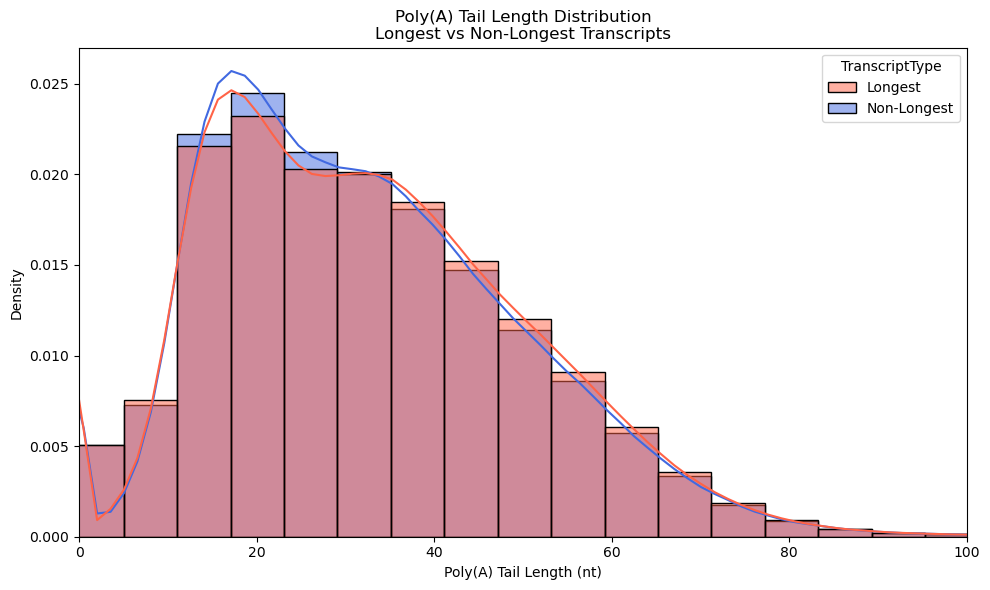

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
longest = pd.read_csv("/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_overlapping_longest_peaks.tsv", sep="\t")
nonlongest = pd.read_csv("/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/polya/polya_overlapping_nonlongest_peaks.tsv", sep="\t")

# Label each dataset
longest["TranscriptType"] = "Longest"
nonlongest["TranscriptType"] = "Non-Longest"
combined = pd.concat([longest, nonlongest], ignore_index=True)

# Clean and filter
combined = combined[pd.to_numeric(combined["polya_length"], errors="coerce").notna()]
combined["polya_length"] = combined["polya_length"].astype(float)
filtered = combined[combined["polya_length"] < 300]

# Plot with correct color palette
plt.figure(figsize=(10, 6))
sns.histplot(
    data=filtered,
    x="polya_length",
    hue="TranscriptType",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    palette={"Longest": "tomato", "Non-Longest": "royalblue"}
)

plt.title("Poly(A) Tail Length Distribution\nLongest vs Non-Longest Transcripts")
plt.xlabel("Poly(A) Tail Length (nt)")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


## 7.6 For each transcript/isoform, which reads overlapped a peak within that transcript/isoform.

### 7.6.1 Create peaks.bed from .saf file


In [ ]:
## path: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_stranded_saf.bed
## see section 7.5.1 

### 7.6.2 Create all_transcripts.bed from your full GTF

In [271]:
%%bash

awk '$3 == "transcript" {
    for (i=1; i<=NF; i++) {
        if ($i == "transcript_id") {
            gsub(/"/, "", $(i+1));
            transcript_id = $(i+1);
        }
    }
    print $1"\t"($4-1)"\t"$5"\t"transcript_id"\t0\t"$7;
}' /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/New_annotation/narrowpeak_transcripts_trim30_2.gtf \
> /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/all_transcripts.bed


### 7.6.3 Once this runs, you’ll have:

    peaks_in_all_transcripts.bed: Peaks inside any transcript

    reads_peaks_transcripts.bed: Reads overlapping those peaks (ready for analysis)

In [286]:
%%bash

module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_stranded_saf.bed \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/all_transcripts.bed \
  -s -wa -wb \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_with_transcript_info.bed


In [283]:
%%bash

module load BEDTools/2.31.1

bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_with_transcript_info.bed \
  -bed -s -wa -wb \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_with_txinfo.bed


In [284]:
import pandas as pd

# Load the file
bed_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_with_txinfo.bed"

# Define column names manually
cols = [
    "read_chr", "read_start", "read_end", "read_id", "score", "read_strand",
    "thick_start", "thick_end", "item_rgb", "block_count", "block_sizes", "block_starts",
    "peak_chr", "peak_start", "peak_end", "peak_id", "peak_score", "peak_strand",
    "tx_chr", "tx_start", "tx_end", "transcript_id", "tx_score", "tx_strand"
]

df = pd.read_csv(bed_path, sep="\t", header=None, names=cols)

# Clean transcript_id (remove trailing semicolon if any)
df["transcript_id"] = df["transcript_id"].str.replace(";", "", regex=False)

# Group by peak and transcript, and collect unique read IDs
grouped = (
    df.groupby(["peak_id", "transcript_id"])["read_id"]
    .unique()
    .reset_index()
    .rename(columns={"read_id": "read_names"})
)

# Add read count
grouped["read_count"] = grouped["read_names"].apply(len)

# Save output
output_path = bed_path.replace(".bed", "_read_names.tsv")
grouped.to_csv(output_path, sep="\t", index=False)

print("Saved to:", output_path)


Saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_with_txinfo_read_names.tsv


In [287]:
import pandas as pd

# === File Paths ===
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_with_txinfo.bed"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_names_per_peak_transcript_filtered.tsv"

# === Column Names (based on bedtools intersect output)
columns = [
    "read_chr", "read_start", "read_end", "read_id", "score", "strand",
    "thick_start", "thick_end", "item_rgb", "block_count", "block_sizes", "block_starts",
    "peak_chr", "peak_start", "peak_end", "peak_id", "peak_score", "peak_strand",
    "tx_chr", "tx_start", "tx_end", "transcript_id", "tx_score", "tx_strand"
]

# === Load Data ===
df = pd.read_csv(input_path, sep="\t", header=None, names=columns)

# === Extract simple peak_id (without _positive/_negative suffix)
df["peak_base"] = df["peak_id"].str.extract(r"(last30_2_peak_\d+)")
df["transcript_base"] = df["transcript_id"].str.extract(r"(last30_2_peak_\d+)")

# === Filter: Only keep rows where the peak_id matches the transcript_id
df_filtered = df[df["peak_base"] == df["transcript_base"]]

# === Group by transcript and peak, and collect unique read IDs
grouped = df_filtered.groupby(["transcript_id", "peak_id"])["read_id"].unique().reset_index()

# === Add read count
grouped["read_count"] = grouped["read_id"].apply(len)

# === Rename for output
grouped.rename(columns={"read_id": "read_names"}, inplace=True)

# === Save Output
grouped.to_csv(output_path, sep="\t", index=False)

print(f"Done. Saved filtered read names per peak/transcript to:\n{output_path}")


Done. Saved filtered read names per peak/transcript to:
/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_names_per_peak_transcript_filtered.tsv


In [296]:
import pandas as pd

# === File Paths ===
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_with_txinfo.bed"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_names_per_peak_transcript_filtered_improved.tsv"

# === Column Names (based on bedtools intersect output)
columns = [
    "read_chr", "read_start", "read_end", "read_id", "score", "strand",
    "thick_start", "thick_end", "item_rgb", "block_count", "block_sizes", "block_starts",
    "peak_chr", "peak_start", "peak_end", "peak_id", "peak_score", "peak_strand",
    "tx_chr", "tx_start", "tx_end", "transcript_id", "tx_score", "tx_strand"
]

# === Load Data ===
df = pd.read_csv(input_path, sep="\t", header=None, names=columns)

# === Extract base peak and transcript IDs
df["peak_base"] = df["peak_id"].str.extract(r"(last30_2_peak_\d+)")
df["transcript_base"] = df["transcript_id"].str.extract(r"(last30_2_peak_\d+)")
df["gene_id"] = df["transcript_id"].str.extract(r"(^[\w\d]+)")  # Extract gene name from transcript_id

# === Filter: Keep only exact peak-transcript matches
df_filtered = df[df["peak_base"] == df["transcript_base"]]

# === Group by transcript and peak, collect read names and count
grouped = df_filtered.groupby(["gene_id", "transcript_id", "peak_id"])["read_id"].agg(
    read_names=lambda x: ";".join(sorted(set(x))),  # Join read IDs in one line
    read_count="count"
).reset_index()

# === Save Output
grouped.to_csv(output_path, sep="\t", index=False)

print(f" Done. Saved filtered read names per peak/transcript to:\n{output_path}")


 Done. Saved filtered read names per peak/transcript to:
/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_names_per_peak_transcript_filtered_improved.tsv


In [297]:
import pandas as pd
import re

# === File Paths ===
input_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_with_txinfo.bed"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_names_per_peak_transcript_filtered_improved1.tsv"

# === Column Names (based on bedtools intersect output)
columns = [
    "read_chr", "read_start", "read_end", "read_id", "score", "strand",
    "thick_start", "thick_end", "item_rgb", "block_count", "block_sizes", "block_starts",
    "peak_chr", "peak_start", "peak_end", "peak_id", "peak_score", "peak_strand",
    "tx_chr", "tx_start", "tx_end", "transcript_id", "tx_score", "tx_strand"
]

# === Load Data ===
df = pd.read_csv(input_path, sep="\t", header=None, names=columns)

# === Extract simple peak_id (without _positive/_negative suffix)
df["peak_base"] = df["peak_id"].str.extract(r"(last30_2_peak_\d+)")
df["transcript_base"] = df["transcript_id"].str.extract(r"(last30_2_peak_\d+)")

# === Filter to keep only rows where peak matches transcript
df_filtered = df[df["peak_base"] == df["transcript_base"]].copy()

# === Extract gene_id as the first part of transcript_id
df_filtered["gene_id"] = df_filtered["transcript_id"].str.extract(r"^([^_]+)")

# === Group and aggregate
grouped = (
    df_filtered.groupby(["gene_id", "transcript_id", "peak_id"])["read_id"]
    .agg(lambda x: ";".join(sorted(set(x))))  # unique + sorted + semicolon-separated
    .reset_index()
)

# === Add read count
grouped["read_count"] = grouped["read_id"].apply(lambda x: len(x.split(";")))

# === Rename column for clarity
grouped.rename(columns={"read_id": "read_names"}, inplace=True)

# === Save as tab-separated
grouped.to_csv(output_path, sep="\t", index=False)

print(f"Output saved to:\n{output_path}")


Output saved to:
/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_names_per_peak_transcript_filtered_improved1.tsv


In [273]:
%%bash

module load BEDTools/2.31.1

# 1. Get peaks that fall within any transcript
bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_stranded_saf.bed \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/all_transcripts.bed \
  -s -u \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_in_all_transcripts.bed

# 2. Get reads overlapping those peaks
bedtools intersect \
  -a /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Trimming/output_reverseCorrected_last30_sorted.bam \
  -b /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/peaks_in_all_transcripts.bed \
  -bed -s -wa -wb \
  > /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts.bed


### 7.6.4 Get the read names per transcripts 

In [275]:
import pandas as pd

# Load the BED file
file_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts.bed"
df = pd.read_csv(file_path, sep="\t", header=None)

# Column positions
READ_NAME_COL = 3
PEAK_NAME_COL = 15

# Extract transcript and peak from column 15
# Assumes format like: chrX	start	end	transcript|peak_id	...
peak_info = df[PEAK_NAME_COL].astype(str)

# Parse into two columns
df["transcript_id"] = peak_info.str.extract(r'([^\|]+)')
df["peak_id"] = peak_info.str.extract(r'(last30_2_peak_\d+)')

# Group by transcript and peak, collect read names
grouped = df.groupby(["transcript_id", "peak_id"])[READ_NAME_COL].unique().reset_index()
grouped.columns = ["transcript_id", "peak_id", "read_names"]
grouped["read_count"] = grouped["read_names"].apply(len)

# Save
output_file = file_path.replace(".bed", "_reads_per_peak_transcript.tsv")
grouped.to_csv(output_file, sep="\t", index=False)
print(f"Saved: {output_file}")


Saved: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_reads_per_peak_transcript.tsv


### Annotate Read Counts per Peak with Gene ID and Strand from Summary Table

In [278]:
import pandas as pd

# === File Paths ===
reads_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_reads_per_peak_transcript.tsv"
summary_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_correct_read_counts.csv"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_with_gene_strand.tsv"

# === Load Files ===
reads_df = pd.read_csv(reads_path, sep="\t")
summary_df = pd.read_csv(summary_path)

# === Extract Peak ID from transcript_id
reads_df["peak_id"] = reads_df["transcript_id"].str.extract(r"(last30_2_peak_\d+)")
reads_df["strand_from_name"] = reads_df["transcript_id"].apply(
    lambda x: "-" if "negative" in x else "+" if "positive" in x else "?"
)

# === Merge gene and strand info
summary_subset = summary_df[["BasePeakID", "gene_id", "transcript_strand"]]
summary_subset.columns = ["peak_id", "gene_id", "strand"]

merged = reads_df.merge(summary_subset, on="peak_id", how="left")

# === Select and Save Final Data
final_df = merged[["gene_id", "transcript_id", "strand", "read_names", "read_count"]]
final_df.to_csv(output_path, sep="\t", index=False)

print(" File saved to:", output_path)


 File saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/reads_peaks_transcripts_with_gene_strand.tsv


### 7.6.6 calculate the median poly(A) tail length per transcript or gene, based on overlapping reads
For each transcript (or gene), find which reads overlap with poly(A) tail length data, and compute the median poly(A) length = poly(A) tail length quantification for transcript-specific mapped reads based on your custom annotation.

To compute poly(A) tail statistics (specifically the median length) for each transcript/peak combination, using only high-quality reads (qc_tag == PASS).

In [279]:
import pandas as pd

# === File Paths ===
reads_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/read_names_per_peak_transcript_filtered_improved.tsv"
polya_path = "/home/saif/Documents/Saif_project_Yeast/Inputs/Saif/longReads/polya/Scer.line.5.tsv"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/polya_stats_all.tsv"

# === Load Read Names Data ===
reads_df = pd.read_csv(reads_path, sep="\t", dtype=str)
reads_df["transcript_id"] = reads_df["transcript_id"].str.strip().str.replace(";", "", regex=False)

# === Load PolyA Data and skip malformed rows ===
cols = [
    "readname", "contig", "position", "leader_start", "adapter_start",
    "polya_start", "transcript_start", "read_rate", "polya_length", "qc_tag"
]
polya_df = pd.read_csv(polya_path, sep="\t", names=cols, header=0, on_bad_lines='skip')

# === Keep only PASS entries
polya_df = polya_df[polya_df["qc_tag"] == "PASS"]

# === Initialize result container
results = []

# === Iterate through each row
for idx, row in reads_df.iterrows():
    gene_id = row["gene_id"]
    transcript_id = row["transcript_id"]
    peak_id = row["peak_id"]
    
    read_names = row["read_names"].split(";")
    read_names = [r.strip() for r in read_names if r.strip()]
    
    matching_polya = polya_df[polya_df["readname"].isin(read_names)]
    
    if not matching_polya.empty:
        median_polya = round(matching_polya["polya_length"].median(), 2)
        num_reads_with_polya = matching_polya.shape[0]
    else:
        median_polya = -1
        num_reads_with_polya = 0
    
    total_mapped_reads = len(read_names)
    
    results.append({
        "gene_id": gene_id.split("_")[0],  # Extract only gene name like Q0045
        "transcript_id": transcript_id,
        "peak_id": peak_id,
        "median_polya_length": median_polya,
        "num_reads_with_polya": num_reads_with_polya,
        "total_mapped_reads": total_mapped_reads
    })

# === Save Output
results_df = pd.DataFrame(results)
results_df.to_csv(output_path, sep="\t", index=False)

print(f"Saved polyA stats for all transcripts to:\n{output_path}")


Output saved to: /home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/gene_transcript_polya_medians.tsv


### 7.6.7 To add median_polya_length and num_reads_with_polya from polya_stats_all.tsv to summary1_with_correct_read_counts.csv, you can perform a merge on gene_id and transcript_id.

In [299]:
import pandas as pd

# === File Paths ===
polya_stats_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/polya_stats_all.tsv"
summary_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_correct_read_counts.csv"
output_path = "/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_polya_stats.csv"

# === Load Data ===
polya_df = pd.read_csv(polya_stats_path, sep="\t")
summary_df = pd.read_csv(summary_path)

# === Merge only on transcript_id
merged_df = pd.merge(
    summary_df,
    polya_df[["transcript_id", "median_polya_length", "num_reads_with_polya"]],
    on="transcript_id",
    how="left"
)

# === Fill missing polyA values with 0
merged_df[["median_polya_length", "num_reads_with_polya"]] = merged_df[["median_polya_length", "num_reads_with_polya"]].fillna(0)

# === Optional: convert types
merged_df["num_reads_with_polya"] = merged_df["num_reads_with_polya"].astype(int)

# === Save result
merged_df.to_csv(output_path, index=False)

print(f"Saved merged summary with polyA stats to:\n{output_path}")


Saved merged summary with polyA stats to:
/home/saif/Documents/Saif_project_Yeast/approach2/outputs_approach2/Quantification_Statistics/summary1_with_polya_stats.csv
